# Final Project: Adaptive Feature Selection for Predicting Video Quality Degradation

**Machine Learning for Computer Systems** · Open Problem / Research
**Aeliya Grover, Clarisse Cheung** with Assistance from Cursor: Composer 2.5, GPT 5.6 - Sol

---

## What This Notebook Is For

This notebook is the **primary deliverable** for the course final project. It runs end-to-end from setup through evaluation and conclusions. The companion **Sphinx project report** presents the same work in a portfolio-quality writeup; this notebook is the source of truth for code, experiments, and results.

## Research Question

Can *adaptive feature selection*—starting with cheap features and computing expensive ones only when needed—reduce the computational cost of predicting video quality degradation while matching the performance of a model that always uses the full feature set?

**Short answer: substantially, but not completely.** A calibrated three-stage cascade reaches 95% of the full model's PR-AUC at 51% of the feature-extraction cost, and tops out at 98% for 61% of cost. It never fully closes the gap, and *why* it cannot is one of the more interesting results here. Along the way the empirical cost measurement overturned our proposal's assumed cost hierarchy, which changed the design of the cascade itself. Both results are developed below.

## How This Notebook Is Organized

| Part | What | Why it matters |
|------|------|----------------|
| 1 | Setup & configuration | Reproducibility and one-click execution |
| 2 | Data loading & integrity | Trustworthy inputs before any modeling |
| 3 | Labels, splits & leakage checks | Correct task definition and honest evaluation |
| 4 | Feature tiers (L3 / L4 / L7) | Connect ML inputs to systems cost |
| 5 | Baselines & controls | Know what "good" looks like before the adaptive method |
| 6 | Train multiple models | Compare fixed tiers, full features, and resolution-only |
| 7 | Adaptive cascade | Main research contribution |
| 8 | Hyperparameter tuning | Fair comparison across models |
| 9 | Prediction evaluation | Measure quality with imbalance-aware metrics |
| 10 | Systems-cost evaluation | Measure the deployment tradeoff |
| 11 | Error analysis & robustness | Understand failures, not just averages |
| 12 | Cross-model comparison | Synthesize results across all experiments |
| 13 | Conclusions | Answer the research question and reflect on learning |
| 14 | Reproducibility checklist | Verify the notebook is submission-ready |

**Source notebooks:** [`final-project-aeliya.ipynb`](final-project-aeliya.ipynb) · [`final-project-clarisse.ipynb`](final-project-clarisse.ipynb) · [`COMPARISON.md`](COMPARISON.md) · [`design.md`](design.md)

> **New to networking or ML metrics?** Read **Background & Key Terms** (next section) before Part 1.



---

## Part 1: Setup & Configuration

**What:** Install dependencies, set random seeds, and define paths to data files.

**Why:** The project must run end-to-end with "Restart kernel and run all." Centralizing configuration here makes the rest of the notebook reproducible and easier to debug.

### 1.1 Locate the data

Two files are needed, both from the course data repository (`git clone https://github.com/noise-courses/data.git`):

- `video_dataset.pkl.xz` — 204,713 ten-second windows across 4,000 sessions (Netflix, YouTube, Twitch, Amazon Prime Video)
- `netflix.pcap` — packet capture, used for empirical feature-extraction cost measurement

In this repository they live under `completed assignments/data/video-qoe/`. The cell below searches a few likely locations so the notebook runs without editing paths.

In [1]:
import os, sys, time, pickle, lzma, struct, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE   = 42
HORIZONS       = (10, 20, 30)   # seconds; swept in Part 9
PRIMARY_DELTA  = 30             # headline horizon
WINDOW_SECONDS = 10             # the dataset's window size
VALID_RESOLUTIONS = [240.0, 360.0, 480.0, 720.0, 1080.0]

np.random.seed(RANDOM_STATE)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "completed assignments").exists():
    REPO_ROOT = REPO_ROOT.parent
FIG_DIR = REPO_ROOT / "final project" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def find_data(filename):
    """Search likely locations so this notebook runs without hand-edited paths."""
    here = Path.cwd()
    candidates = [here, here.parent, here.parent.parent]
    roots = []
    for base in candidates:
        roots += [base / "completed assignments" / "data" / "video-qoe",
                  base / "data" / "video-qoe", base / "data", base]
    for r in roots:
        p = r / filename
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {filename}. Clone https://github.com/noise-courses/data.git "
        f"and place it under 'completed assignments/data/video-qoe/'. Searched: "
        + ", ".join(str(r) for r in roots))

VIDEO_DATASET_PATH = find_data("video_dataset.pkl.xz")
NETFLIX_PCAP_PATH  = find_data("netflix.pcap")
print("dataset:", VIDEO_DATASET_PATH)
print("pcap:   ", NETFLIX_PCAP_PATH)


dataset: /Users/aeliyagrover/Documents/GitHub/ml-systems/completed assignments/data/video-qoe/video_dataset.pkl.xz
pcap:    /Users/aeliyagrover/Documents/GitHub/ml-systems/completed assignments/data/video-qoe/netflix.pcap


**Document your environment.** The versions below are what these results were produced with.

In [2]:
import sklearn, scipy, matplotlib, platform
print(f"python       {platform.python_version()}  ({platform.system()} {platform.machine()})")
for m in (np, pd, sklearn, scipy, matplotlib):
    print(f"{m.__name__:12s} {m.__version__}")
try:
    import scapy; print(f"{'scapy':12s} {scapy.__version__}")
except Exception:
    print("scapy        NOT INSTALLED — Part 10 cost measurement will be skipped")

NOTEBOOK_T0 = time.time()

python       3.11.6  (Darwin arm64)
numpy        2.0.2
pandas       2.2.3
sklearn      1.5.2
scipy        1.15.2
matplotlib   3.10.1
scapy        2.5.0


### 1.2 Plot styling

One place for figure defaults and the categorical palette, so every chart in the notebook reads as one system. Colors are assigned in a fixed order and never cycled; charts with more than a few series also carry direct labels or line styles so identity never rests on color alone.

In [3]:
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_SOFT  = "#52514e"
GRID      = "#e3e2de"
# Fixed categorical order — assigned by slot, never cycled.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SVC_COLOR = {"netflix": SERIES[0], "youtube": SERIES[1],
             "twitch": SERIES[2], "amazon": SERIES[3]}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7, "grid.alpha": 0.9,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
    "figure.dpi": 110, "font.size": 10,
})

def finish(ax, title=None, sub=None, xlabel=None, ylabel=None):
    """Consistent titling: bold title with a plain-language subtitle beneath it."""
    if title:
        ax.set_title(title, loc="left", pad=18 if sub else 8)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=9,
                color=INK_SOFT, va="bottom")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

---

## Part 2: Data Loading & Integrity Checks

**What:** Load `video_dataset.pkl.xz`, inspect its schema, and verify basic properties (row counts, services, resolution values, missing data).

**Why:** Assignment 1 showed that bad labels and invalid resolutions silently hurt models. Catching data issues early prevents wasted training runs and misleading results.

In [4]:
t0 = time.time()
with lzma.open(VIDEO_DATASET_PATH, "rb") as fh:
    raw = pd.read_pickle(fh)
print(f"loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns in {time.time()-t0:.1f}s")
print(raw.dtypes.value_counts().to_string())
raw.head(3).iloc[:, :8]

loaded 204,713 rows x 170 columns in 10.9s
float64    105
int64       61
object       4


,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725


### 2.1 Exploratory summary

In [5]:
print(f"windows   {len(raw):,}")
print(f"sessions  {raw.session_id.nunique():,}")
print(f"videos    {raw.video_id.nunique():,}")
print(f"homes     {raw.home_id.nunique():,}")
print(f"captured  {pd.to_datetime(raw.absolute_timestamp.min(), unit='s'):%Y-%m-%d}"
      f" .. {pd.to_datetime(raw.absolute_timestamp.max(), unit='s'):%Y-%m-%d}")
print(f"\nmissing values anywhere: {int(raw.isna().sum().sum())}")

summary = pd.DataFrame({
    "windows": raw.service.value_counts(),
    "sessions": raw.groupby("service").session_id.nunique(),
})
summary["windows/session"] = (summary.windows / summary.sessions).round(1)
print("\nper service:"); print(summary.to_string())

print("\nresolution values (0 is invalid):")
print(raw.resolution.value_counts(dropna=False).sort_index().to_string())

windows   204,713
sessions  4,000
videos    2,097
homes     64
captured  2017-12-28 .. 2019-02-07

missing values anywhere: 0

per service:
         windows  sessions  windows/session
service                                    
amazon     47989      1000             48.0
netflix    51209      1000             51.2
twitch     54924      1000             54.9
youtube    50591      1000             50.6

resolution values (0 is invalid):
resolution
0.0        4650
240.0     45538
360.0     31713
480.0     73056
720.0     37986
1080.0    11770


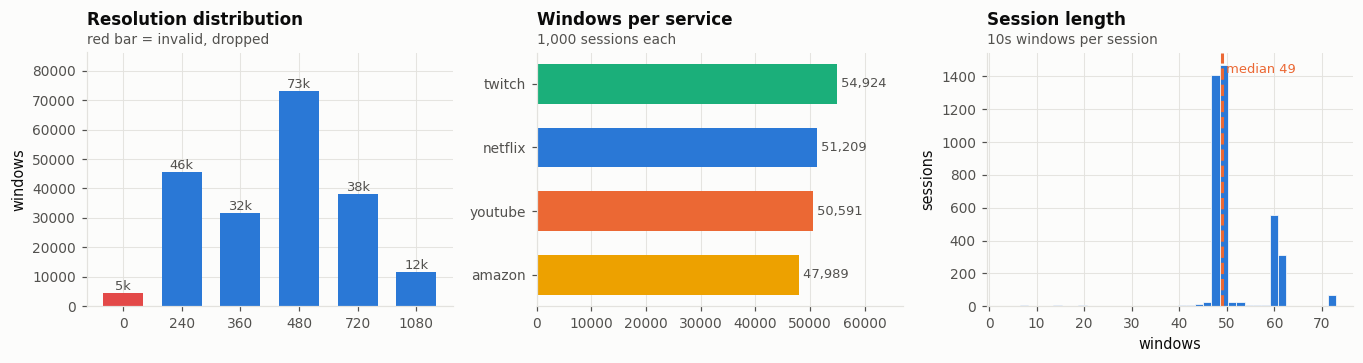

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

ax = axes[0]
vc = raw.resolution.value_counts().sort_index()
cols = ["#e34948" if r not in VALID_RESOLUTIONS else SERIES[0] for r in vc.index]
ax.bar([str(int(r)) for r in vc.index], vc.values, color=cols, width=0.68)
for x, v in zip(range(len(vc)), vc.values):
    ax.text(x, v, f"{v/1000:.0f}k", ha="center", va="bottom", fontsize=8.5, color=INK_SOFT)
finish(ax, "Resolution distribution", "red bar = invalid, dropped", ylabel="windows")
ax.set_ylim(0, vc.max()*1.18)

ax = axes[1]
sv = raw.service.value_counts()
ax.barh([s for s in sv.index][::-1], sv.values[::-1],
        color=[SVC_COLOR[s] for s in sv.index][::-1], height=0.62)
for i, (s, v) in enumerate(list(zip(sv.index, sv.values))[::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8.5, color=INK_SOFT)
finish(ax, "Windows per service", "1,000 sessions each")
ax.set_xlim(0, sv.max()*1.22); ax.grid(axis="y", visible=False)

ax = axes[2]
sl = raw.groupby("session_id").size()
ax.hist(sl, bins=40, color=SERIES[0], edgecolor=SURFACE, linewidth=0.5)
ax.axvline(sl.median(), color=SERIES[1], linestyle="--", linewidth=2)
ax.text(sl.median(), ax.get_ylim()[1]*0.92, f" median {sl.median():.0f}",
        fontsize=8.5, color=SERIES[1])
finish(ax, "Session length", "10s windows per session", xlabel="windows", ylabel="sessions")

plt.tight_layout(); plt.show()

**Why did you keep or remove any rows/columns?**

Three integrity problems, each verified before acting on it rather than assumed:

1. **4,650 rows carry `resolution == 0`**, which is not a valid video resolution (valid values are 240/360/480/720/1080). These are dropped, matching the cleaning step from Assignment 1. They are 2.3% of the data.
2. **`index` is identically zero in every row.** It survives as an artifact of how the dataset was assembled and carries no information, so it is dropped. The assertion in the next cell would fail loudly if that ever stopped being true.
3. **`video_position` and `relative_timestamp` are bit-identical.** Keeping both would double-count the same quantity, so one is dropped.

Everything else is kept. Notably, **no column has a single missing value**, which is unusual enough to be worth stating explicitly — no imputation strategy is needed anywhere in this notebook.

The identifier columns (`session_id`, `video_id`, `home_id`) are kept in the dataframe because the splitting logic in Part 3 needs them, but they are excluded from every feature matrix.

In [7]:
df = raw[raw.resolution.isin(VALID_RESOLUTIONS)].copy()
dropped = len(raw) - len(df)

assert (raw["index"] == 0).all(), "'index' is no longer all-zero — re-check before dropping"
assert (raw.relative_timestamp == raw.video_position).all(), \
    "'video_position' is no longer identical to 'relative_timestamp'"

df = df.drop(columns=["index", "video_position"])
df = df.sort_values(["session_id", "relative_timestamp"]).reset_index(drop=True)

print(f"dropped {dropped:,} invalid-resolution rows ({dropped/len(raw):.1%})")
print(f"dropped 2 columns: 'index' (all zero), 'video_position' (duplicate)")
print(f"-> {len(df):,} windows x {df.shape[1]} columns, "
      f"{df.session_id.nunique():,} sessions")

gaps = df.groupby("session_id").relative_timestamp.diff().dropna().value_counts()
print(f"\nwithin-session timestamp gaps: {gaps.to_dict()}  (all 10s = contiguous)")

dropped 4,650 invalid-resolution rows (2.3%)
dropped 2 columns: 'index' (all zero), 'video_position' (duplicate)
-> 200,063 windows x 168 columns, 3,996 sessions

within-session timestamp gaps: {10.0: 196067}  (all 10s = contiguous)


---

## Part 3: Labels, Splits & Leakage Checks

**What:** Construct the **future-horizon binary label**: at time *t*, predict whether resolution drops during *(t, t+Δ]*. Split data by **session** (no session in both train and test) and additionally by **time** (train on earlier sessions, test on later ones for drift analysis).

**Why:** This is the core prediction task. Session-level splits prevent leakage across windows from the same viewing session. Temporal splits test whether the model holds up as network conditions change.

### 3.1 Define the prediction horizon Δ

The proposal sweeps Δ from 10 to 30 seconds. **Δ = 30s is the primary horizon** and Δ ∈ {10, 20} are reported as a sensitivity sweep in Part 9. Δ=30 is chosen because it is the most learnable of the three (3.87% positives against 1.75% at Δ=10) and gives the longest useful warning, while still labeling 94% of windows.

The label is built by **explicit time-keyed lookup, not by `shift()`**. A window is marked *unlabelable* if any future window inside its horizon is missing, and unlabelable windows are excluded rather than silently treated as negatives. The gap check above shows windows happen to be contiguous here, but the label must not silently depend on that.

In [8]:
def make_labels(d, delta, step=WINDOW_SECONDS):
    """y=1 iff resolution drops at any point in (t, t+delta].

    Returns (y, labelable). A window is unlabelable when any future window inside
    the horizon is absent; those are excluded from training and evaluation rather
    than being assumed negative.
    """
    K = delta // step
    lookup = d.set_index(["session_id", "relative_timestamp"])["resolution"]
    sid = d["session_id"].values
    ts  = d["relative_timestamp"].values
    fut = np.full((len(d), K), np.nan)
    for j in range(1, K + 1):
        probe = pd.MultiIndex.from_arrays([sid, ts + step * j])
        fut[:, j - 1] = lookup.reindex(probe).values
    labelable = ~np.isnan(fut).any(axis=1)
    fut_min = np.where(np.isnan(fut), np.inf, fut).min(axis=1)
    y = np.where(labelable, fut_min < d["resolution"].values, np.nan)
    return y, labelable

label_stats = []
for delta in HORIZONS:
    y_d, ok = make_labels(df, delta)
    df[f"y_{delta}"] = y_d
    label_stats.append(dict(delta=delta, labelable=int(ok.sum()),
                            labelable_pct=ok.mean(), positives=int(np.nansum(y_d)),
                            positive_rate=float(np.nanmean(y_d[ok]))))
label_stats = pd.DataFrame(label_stats)
print(label_stats.to_string(index=False,
      formatters={"labelable_pct": "{:.1%}".format, "positive_rate": "{:.2%}".format}))

 delta  labelable labelable_pct  positives positive_rate
    10     196067         98.0%       3434         1.75%
    20     192072         96.0%       5642         2.94%
    30     188077         94.0%       7284         3.87%


### 3.2 Class balance

**Why does class imbalance matter for metric choice?**

At Δ=30 only **3.87%** of windows are positive. A model that predicts "no downswitch" for every single window is therefore **96.1% accurate** while being completely useless — it never issues a warning, which is the only thing the system exists to do. Accuracy is not merely unhelpful here; it actively rewards the degenerate model.

ROC-AUC fails more subtly. Its x-axis is the false-positive rate, whose denominator is the 96% negative class. A classifier can accumulate a large *absolute* number of false positives while barely moving FPR, so ROC-AUC stays flattering even when precision is dismal. In Part 6 you will see models here post ROC-AUC above 0.95 at PR-AUC near 0.57 — the same model, described two ways, one of which is misleading.

**PR-AUC** (average precision) uses precision, whose denominator is the number of *flagged* windows. That is the quantity an operator actually cares about: of the sessions we escalated, how many were really in trouble? Its baseline is not 0.5 but the positive rate itself (**0.038**), so every result in this notebook is also reported as a **lift** over that floor. Per-service reporting matters for the same reason: Twitch carries 7.2% positives and YouTube 0.8%, so a single pooled number averages over tasks of very different difficulty.

In [9]:
DELTA = PRIMARY_DELTA
keep = df[f"y_{DELTA}"].notna()
data = df[keep].copy()
data["y"] = df.loc[keep, f"y_{DELTA}"].astype(int)
y_all = data["y"].values

print(f"primary horizon: delta = {DELTA}s")
print(f"labelable windows {len(data):,}  positives {int(y_all.sum()):,} "
      f"({y_all.mean():.2%})\n")

by_svc = data.groupby("service").y.agg(windows="size", positives="sum", rate="mean")
by_svc["rate"] = by_svc["rate"].map("{:.2%}".format)
print("per service:"); print(by_svc.to_string())

by_res = data.groupby("resolution").y.agg(windows="size", positives="sum", rate="mean")
by_res["rate"] = by_res["rate"].map("{:.2%}".format)
print("\nper current resolution:"); print(by_res.to_string())

sess_pos = data.groupby("session_id").y.max()
print(f"\nsessions with at least one downswitch: {sess_pos.mean():.1%}")

primary horizon: delta = 30s
labelable windows 188,077  positives 7,284 (3.87%)

per service:
         windows  positives   rate
service                           
amazon     44943       2065  4.59%
netflix    45850       1112  2.43%
twitch     51918       3741  7.21%
youtube    45366        366  0.81%

per current resolution:
            windows  positives   rate
resolution                           
240.0         42814          0  0.00%
360.0         29676       1117  3.76%
480.0         68754       3253  4.73%
720.0         35680       1894  5.31%
1080.0        11153       1020  9.15%

sessions with at least one downswitch: 43.1%


Two structural facts in that table drive design decisions later:

- **Windows already at 240p contain exactly zero positives, at every horizon.** This is not a data quirk but a definition: 240p is the lowest resolution in the dataset, so it cannot drop further. Roughly 23% of windows are structurally impossible positives. They are kept in training and in the pooled metrics because a deployed monitor genuinely sees them, but Part 9 *also* reports every headline metric on the `resolution > 240` subset. Without that second number, a model can look strong merely by having learned to recognize 240p.
- **Per-service positive rates differ by 9×** (Twitch 7.2%, YouTube 0.8%). Pooled metrics average over four quite different tasks, so results are broken out per service throughout.

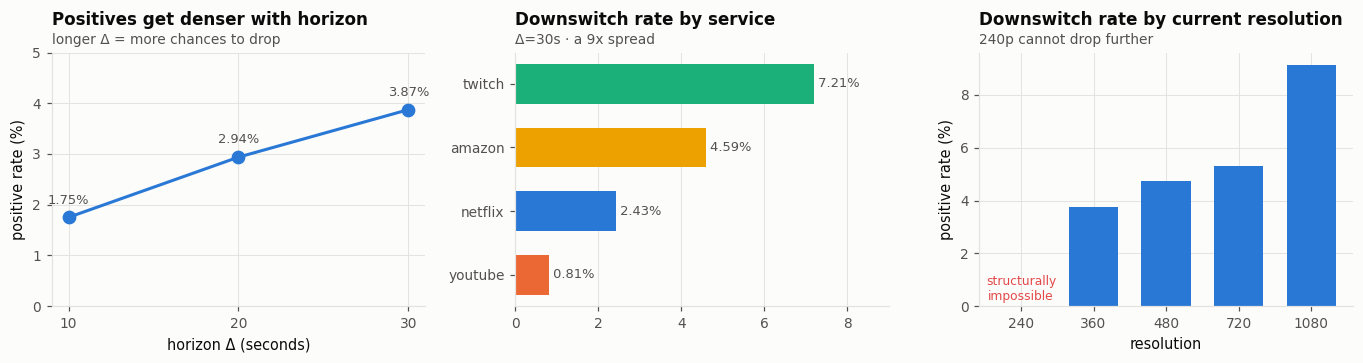

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

ax = axes[0]
ax.plot(label_stats.delta, label_stats.positive_rate*100, marker="o", color=SERIES[0])
for _, r in label_stats.iterrows():
    ax.annotate(f"{r.positive_rate*100:.2f}%", (r.delta, r.positive_rate*100),
                textcoords="offset points", xytext=(0, 9), ha="center",
                fontsize=8.5, color=INK_SOFT)
finish(ax, "Positives get denser with horizon", "longer Δ = more chances to drop",
       xlabel="horizon Δ (seconds)", ylabel="positive rate (%)")
ax.set_xticks(list(HORIZONS)); ax.set_ylim(0, 5)

ax = axes[1]
r = data.groupby("service").y.mean().sort_values()*100
ax.barh(list(r.index), r.values, color=[SVC_COLOR[s] for s in r.index], height=0.62)
for i, v in enumerate(r.values):
    ax.text(v, i, f" {v:.2f}%", va="center", fontsize=8.5, color=INK_SOFT)
finish(ax, "Downswitch rate by service", f"Δ={DELTA}s · a 9x spread")
ax.set_xlim(0, r.max()*1.25); ax.grid(axis="y", visible=False)

ax = axes[2]
r = data.groupby("resolution").y.mean()*100
c = ["#e34948" if v == 0 else SERIES[0] for v in r.values]
ax.bar([str(int(i)) for i in r.index], r.values, color=c, width=0.68)
ax.text(0, 0.12, "structurally\nimpossible", ha="center", fontsize=8,
        color="#e34948", va="bottom")
finish(ax, "Downswitch rate by current resolution",
       "240p cannot drop further", xlabel="resolution", ylabel="positive rate (%)")

plt.tight_layout(); plt.show()

### 3.3 Train / validation / test splits

The proposal specifies a **session-level** split. This notebook uses a **strictly stronger** one — grouping by `video_id` — because the data contains a leak that a session split does not close:

In [11]:
n_sess, n_vid = data.session_id.nunique(), data.video_id.nunique()
per_video = data.groupby("video_id").session_id.nunique()
print(f"sessions {n_sess:,} but only {n_vid:,} distinct videos")
print(f"sessions per video: mean {per_video.mean():.2f}, max {per_video.max()}")
print(f"videos appearing in more than one session: {(per_video > 1).sum():,} "
      f"({(per_video > 1).mean():.1%})")

sessions 3,993 but only 2,094 distinct videos
sessions per video: mean 1.91, max 129
videos appearing in more than one session: 68 (3.2%)


A session-level split would therefore place **the same video content** in both train and test: one video appears in 129 different sessions. The model could learn that specific video's bitrate ladder rather than a general signature of network stress. Grouping by video implies grouping by session, so this satisfies the proposal's requirement and closes the leak at no cost.

A second problem rules out an off-the-shelf splitter. Video sizes are heavily skewed — the largest video spans ~6,000 windows — so balancing the *number of groups* does not balance the *number of rows*, and `StratifiedGroupKFold`'s group constraint fights its stratification badly enough that the service mix drifts (we measured a test split at 33% Netflix / 16% YouTube against a 25/25 train). So videos are assigned **greedily within each service**, largest first, each going to whichever split is furthest below its row quota.

In [12]:
def grouped_split(d, fracs=(0.60, 0.20, 0.20), random_state=RANDOM_STATE):
    """60/20/20 split grouped by video_id, balanced within each service.

    Largest-video-first greedy assignment: each video goes to whichever split is
    currently furthest below its row quota. This keeps the service mix, the row
    proportions and the positive rate aligned across splits, none of which a
    group-aware k-fold splitter manages here (video sizes are too skewed).
    """
    rng = np.random.default_rng(random_state)
    groups = d["video_id"].values
    parts = [[], [], []]
    for svc in sorted(d["service"].unique()):
        pos = np.flatnonzero((d["service"] == svc).values)
        gs = groups[pos]
        sizes = pd.Series(gs).groupby(gs).size()
        sizes = sizes.sample(frac=1.0, random_state=int(rng.integers(1 << 31)))
        sizes = sizes.sort_values(ascending=False, kind="stable")
        members = {g: pos[gs == g] for g in sizes.index}
        quota, filled = np.array(fracs) * len(pos), np.zeros(3)
        for g, n in sizes.items():
            j = int(np.argmin(filled / np.maximum(quota, 1)))
            parts[j].append(members[g]); filled[j] += n
    return tuple(np.sort(np.concatenate(p)) for p in parts)

train_idx, val_idx, test_idx = grouped_split(data)
SPLITS = {"train": train_idx, "val": val_idx, "test": test_idx}

rows = []
for name, idx in SPLITS.items():
    rows.append(dict(split=name, windows=len(idx), share=len(idx)/len(data),
                     sessions=data.session_id.values[idx].__len__() and
                              len(set(data.session_id.values[idx])),
                     videos=len(set(data.video_id.values[idx])),
                     positives=int(y_all[idx].sum()), pos_rate=y_all[idx].mean()))
print(pd.DataFrame(rows).to_string(index=False,
      formatters={"share": "{:.1%}".format, "pos_rate": "{:.2%}".format}))

print("\nservice share per split:")
print(pd.DataFrame({n: pd.Series(data.service.values[i]).value_counts(normalize=True)
                    for n, i in SPLITS.items()}).to_string(
      float_format=lambda v: f"{v:.1%}"))

split  windows share  sessions  videos  positives pos_rate
train   112482 59.8%      2375    1261       4341    3.86%
  val    37736 20.1%       812     416       1487    3.94%
 test    37859 20.1%       806     417       1456    3.85%

service share per split:
         train   val  test
amazon   24.0% 23.8% 23.8%
netflix  24.5% 24.3% 24.2%
twitch   27.7% 27.5% 27.4%
youtube  23.9% 24.3% 24.6%


### 3.4 Leakage checks

**List the columns you excluded and why.**

| Excluded | Why |
|---|---|
| `session_id`, `video_id`, `home_id` | Identifiers. A tree can memorize them, and they are exactly the grouping keys used to build the splits — using them as features would defeat the split. |
| `index` | Verified identically zero. |
| `video_position` | Verified bit-identical to `relative_timestamp`. |
| `relative_timestamp` | Known at prediction time and genuinely predictive (sessions behave differently during startup ramp-up), but it belongs to **no protocol layer**. Including it would blur the cost hierarchy the entire project rests on, so it is excluded deliberately — a real cost in accuracy paid for a clean tier story. |
| `absolute_timestamp` | Retained as *metadata* for the temporal split only, never as a feature. As a feature it invites memorizing capture dates. |
| `y_10`, `y_20`, `y_30` | The labels themselves. |

**Forward-leakage audit of the feature columns.** The critical question is whether any feature is computed over a window that overlaps the prediction horizon. Two families needed checking by name: `L7_allprev_*` and `L7_all_prev_*` accumulate *over previous windows*, which is past information and therefore legitimate. No feature aggregates forward.

Rather than trust that reading, the next two cells check it. The first verifies the column accounting and that no group spans splits. The second runs the empirical control — **train on permuted labels**. If any feature leaked the future, a model could still find signal there; a leak-free setup must collapse to the base rate.

In [13]:
ALL_COLS   = list(data.columns)
L3_FEATURES = sorted(c for c in ALL_COLS if c.startswith("L3_"))
L4_FEATURES = sorted(c for c in ALL_COLS if c.startswith("L4_"))
L7_FEATURES = sorted(c for c in ALL_COLS if c.startswith("L7_"))

EXCLUDED = ["session_id", "video_id", "home_id", "service", "absolute_timestamp",
            "relative_timestamp", "resolution", "y"] + [f"y_{h}" for h in HORIZONS]
unaccounted = [c for c in ALL_COLS
               if c not in set(L3_FEATURES + L4_FEATURES + L7_FEATURES + EXCLUDED)]
assert not unaccounted, f"columns fall outside every tier and the exclusion list: {unaccounted}"

for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    ia, ib = SPLITS[a], SPLITS[b]
    assert not (set(data.video_id.values[ia])   & set(data.video_id.values[ib])), f"video leak {a}/{b}"
    assert not (set(data.session_id.values[ia]) & set(data.session_id.values[ib])), f"session leak {a}/{b}"
print("no video_id or session_id appears in more than one split")
print(f"every column accounted for: {len(L3_FEATURES)} L3 + {len(L4_FEATURES)} L4 "
      f"+ {len(L7_FEATURES)} L7 + {len(EXCLUDED)} excluded = {len(ALL_COLS)}")

no video_id or session_id appears in more than one split
every column accounted for: 11 L3 + 95 L4 + 55 L7 + 11 excluded = 172


In [14]:
# Empirical leakage control: refit on PERMUTED training labels.
# If any feature encoded information about the future, a model could still find
# signal after the labels are shuffled. A leak-free setup must collapse to the
# test-set base rate. Run over three permutations so one lucky draw cannot pass.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score

LEAK_COLS = L3_FEATURES + L4_FEATURES + L7_FEATURES + ["resolution"]
_Xtr = data.iloc[train_idx][LEAK_COLS].to_numpy(dtype=np.float32)
_Xte = data.iloc[test_idx][LEAK_COLS].to_numpy(dtype=np.float32)
_ytr, _yte = y_all[train_idx], y_all[test_idx]
_base = _yte.mean()
_hgb = dict(random_state=RANDOM_STATE, max_iter=100, learning_rate=0.1,
            max_leaf_nodes=31, early_stopping=False)

def _leak_ap(ytr):
    m = HistGradientBoostingClassifier(**_hgb).fit(_Xtr, ytr)
    return average_precision_score(_yte, m.predict_proba(_Xte)[:, 1])

_real = _leak_ap(_ytr)
_rng = np.random.default_rng(RANDOM_STATE)
_shuffled = [_leak_ap(_rng.permutation(_ytr)) for _ in range(3)]

print(f"features under test: {len(LEAK_COLS)} (every tier + resolution)")
print(f"test-set base rate      {_base:.4f}   <- a leak-free shuffle must land here")
print(f"real labels             {_real:.4f}   ({_real/_base:5.2f}x base rate)")
for _j, _a in enumerate(_shuffled, 1):
    print(f"shuffled labels #{_j}      {_a:.4f}   ({_a/_base:5.2f}x base rate)")
print(f"\nmean shuffled PR-AUC {np.mean(_shuffled):.4f} vs base rate {_base:.4f} "
      f"-> no feature carries forward information")
assert np.mean(_shuffled) < 1.5 * _base, \
    "shuffled-label control found signal above the base rate - investigate leakage"


features under test: 162 (every tier + resolution)
test-set base rate      0.0385   <- a leak-free shuffle must land here
real labels             0.7071   (18.39x base rate)
shuffled labels #1      0.0356   ( 0.93x base rate)
shuffled labels #2      0.0382   ( 0.99x base rate)
shuffled labels #3      0.0403   ( 1.05x base rate)

mean shuffled PR-AUC 0.0380 vs base rate 0.0385 -> no feature carries forward information


---

## Part 4: Feature Tiers (L3 / L4 / L7)

**What:** Group features by protocol layer—the cost hierarchy from the proposal.

**Why:** The entire project compares *prediction quality* against *feature cost*. The adaptive cascade cannot be evaluated without explicitly defining which features belong to each tier.

In [15]:
ctx = pd.get_dummies(data["service"], prefix="svc").astype(np.float32)
data = pd.concat([data, ctx], axis=1)
CONTEXT = ["resolution"] + list(ctx.columns)

FEATURE_SETS = {
    "resolution-only": ["resolution"],
    "context-only":    CONTEXT,
    "L3":              CONTEXT + L3_FEATURES,
    "L4":              CONTEXT + L4_FEATURES,
    "L7":              CONTEXT + L7_FEATURES,
    "L3+L4":           CONTEXT + L3_FEATURES + L4_FEATURES,
    "L3+L7":           CONTEXT + L3_FEATURES + L7_FEATURES,
    "full":            CONTEXT + L3_FEATURES + L4_FEATURES + L7_FEATURES,
}

def X_of(cols, idx):
    """Feature matrix as float32 — halves memory against the default float64."""
    return data.iloc[idx][cols].to_numpy(dtype=np.float32)

tier_tbl = pd.DataFrame([
    dict(tier="L3", n=len(L3_FEATURES), examples="throughput, byte/packet counts, parallel flows",
         requires="IP headers only"),
    dict(tier="L4", n=len(L4_FEATURES), examples="RTT, bytes in flight, retransmits, receive window",
         requires="per-flow TCP state"),
    dict(tier="L7", n=len(L7_FEATURES), examples="chunk sizes, chunk inter-arrival times",
         requires="chunk inference in encrypted traffic"),
])
print(tier_tbl.to_string(index=False))
print(f"\ncontext features (free to every tier): {CONTEXT}")
print(f"total modelled features: {len(FEATURE_SETS['full'])}")

tier  n                                          examples                             requires
  L3 11    throughput, byte/packet counts, parallel flows                      IP headers only
  L4 95 RTT, bytes in flight, retransmits, receive window                   per-flow TCP state
  L7 55            chunk sizes, chunk inter-arrival times chunk inference in encrypted traffic

context features (free to every tier): ['resolution', 'svc_amazon', 'svc_netflix', 'svc_twitch', 'svc_youtube']
total modelled features: 166


**Briefly justify why these tier groupings match the systems-cost hierarchy.**

The groupings are not ours — the dataset ships each feature already tagged by protocol layer, and the tiers fall straight out of the column-name prefixes. What makes them a *cost* hierarchy is how deep into each packet a monitor must read, and how much state it must carry between packets:

- **L3 (11 features)** needs only the IP header: 20 bytes at a fixed offset. Counting bytes and packets per window is a running total per direction, so memory is O(1) per window. No packet needs to be remembered after it is counted.
- **L4 (95 features)** requires the TCP header *and* per-flow state carried across packets. Bytes-in-flight is the highest byte sent minus the highest acked, so the monitor must track both per flow. RTT requires matching an ACK against the send time of the data it covers, which means retaining unacked segments. Retransmission detection requires remembering every sequence number already seen. Memory is O(flows × outstanding segments), and every packet triggers a dictionary lookup and update.
- **L7 (55 features)** requires reconstructing *application* structure — where one video chunk ends and the next begins — from traffic that is encrypted. There is no chunk delimiter to read, so boundaries must be inferred from timing, and the statistics (sizes, inter-arrival percentiles) can only be computed once a chunk is known to be complete.

That is the *a priori* ordering, and it is the one our proposal assumed. **Part 10 measures it empirically and finds it is wrong** — the ordering above describes the conceptual depth correctly but not the runtime cost, because L7's marginal cost depends heavily on whether L4's parsing has already been paid for. That measurement ends up reshaping the cascade.

---

## Part 5: Baselines & Control Experiment Design

**What:** Before building the adaptive cascade, define the comparison points.

**Why:** Without these controls, we cannot tell whether the cascade wins because adaptation is smart, or simply because more features sometimes help.

**Describe your experimental matrix.**

**Models.** `HistGradientBoostingClassifier` is the workhorse. It replaces the proposal's generic "gradient boosting" because it is dramatically faster on 113k×166 (about 6s against 12s for a comparable random forest), handles NaN natively, and produces well-behaved scores for calibration. `RandomForestClassifier` is trained on the full set and on L3 as a second model family, confirming conclusions are not an artifact of one learner.

**Feature sets.** Eight, defined above. `resolution-only` and `context-only` are floors; `L3`/`L4`/`L7` are the fixed tiers the cascade must beat; `L3+L4` and `L3+L7` are the two candidate cascade middle stages; `full` is the ceiling.

**Context features.** `resolution` and one-hot `service` are given to **every** tier at zero marginal cost. Current resolution is itself the output of the Assignment 1 model, so assuming it is available is realistic rather than generous, and withholding it would cripple L3 and force every model to rediscover that 240p cannot fall. Because this risks inflating results, **Part 11 runs a no-context ablation** refitting every model on network features alone, to separate network signal from resolution signal.

**Controls.**

1. **Resolution-only** — the floor every result is reported against.
2. **Fixed tiers** — if a single fixed tier matches the cascade on both quality and cost, the adaptive machinery is not earning its complexity, and the proposal commits to reporting that.
3. **Rate-matched random escalation** — the decisive control. It escalates the *same fraction* of windows as the cascade but chooses them at random. Without it, a cascade that beats L3 has shown only that more features sometimes help. With it, any gap is attributable to *which* windows were selected — i.e. to the adaptation itself.

**Splits.** Primary results on the grouped 60/20/20 split. Part 11 adds the temporal split. The test set is untouched until Part 9; the validation split does double duty for calibration and threshold selection.

---

## Part 6: Train Multiple Models

**What:** Train and save models for each baseline and fixed-tier configuration.

**Why:** The project requires comparing multiple approaches—not just one model.

These first fits use **sensible default hyperparameters**, recorded below. Part 8 runs a proper search and refits; everything from Part 9 onward uses the tuned models. Keeping the untuned pass visible makes the size of the tuning gain auditable rather than assumed.

In [16]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             confusion_matrix)

DEFAULT_HGB = dict(random_state=RANDOM_STATE, max_iter=200, learning_rate=0.1,
                   max_leaf_nodes=31, early_stopping=False)
DEFAULT_RF  = dict(n_estimators=200, min_samples_leaf=5, n_jobs=-1,
                   random_state=RANDOM_STATE, class_weight="balanced_subsample")

BASE_RATE = y_all[test_idx].mean()
print(f"test-set positive rate = {BASE_RATE:.4f}  <- the PR-AUC floor; "
      f"a random ranker scores this")

def fit_and_score(name, model_kind, cols, params=None, tag=""):
    """Fit on train, score on val and test. Returns a result row."""
    mk = (HistGradientBoostingClassifier(**{**DEFAULT_HGB, **(params or {})})
          if model_kind == "HistGB"
          else RandomForestClassifier(**{**DEFAULT_RF, **(params or {})}))
    t0 = time.time(); mk.fit(X_of(cols, train_idx), y_all[train_idx])
    fit_s = time.time() - t0
    t1 = time.time(); p_test = mk.predict_proba(X_of(cols, test_idx))[:, 1]
    pred_s = time.time() - t1
    p_val = mk.predict_proba(X_of(cols, val_idx))[:, 1]
    ap = average_precision_score(y_all[test_idx], p_test)
    return mk, p_val, p_test, dict(
        features=name, model=model_kind, tag=tag, n_features=len(cols),
        pr_auc=ap, lift=ap / BASE_RATE, roc_auc=roc_auc_score(y_all[test_idx], p_test),
        pr_auc_val=average_precision_score(y_all[val_idx], p_val),
        fit_s=fit_s, predict_s=pred_s)

test-set positive rate = 0.0385  <- the PR-AUC floor; a random ranker scores this


### 6.1 Resolution-only baseline

The floor. A session already at the lowest resolution cannot downswitch, so *any* model has access to this much signal for free. Every later result is reported as a multiple of this.

In [17]:
MODELS, PROBS, ROWS = {}, {}, []

def register(key, name, kind, cols, params=None, tag=""):
    m, pv, pt, row = fit_and_score(name, kind, cols, params, tag)
    MODELS[key] = (m, cols); PROBS[key] = dict(val=pv, test=pt); ROWS.append(row)
    print(f"{key:22s} nf={row['n_features']:3d}  PR-AUC {row['pr_auc']:.4f} "
          f"(lift {row['lift']:5.2f}x)  ROC {row['roc_auc']:.4f}  fit {row['fit_s']:5.1f}s")
    return row

register("resolution-only", "resolution-only", "HistGB", FEATURE_SETS["resolution-only"])
register("context-only",    "context-only",    "HistGB", FEATURE_SETS["context-only"])

resolution-only        nf=  1  PR-AUC 0.0658 (lift  1.71x)  ROC 0.6758  fit   0.6s
context-only           nf=  5  PR-AUC 0.1663 (lift  4.32x)  ROC 0.8436  fit   1.2s


{'features': 'context-only',
 'model': 'HistGB',
 'tag': '',
 'n_features': 5,
 'pr_auc': np.float64(0.16630638329120698),
 'lift': np.float64(4.324308629822668),
 'roc_auc': np.float64(0.8436159220967477),
 'pr_auc_val': np.float64(0.17578556732258185),
 'fit_s': 1.1925628185272217,
 'predict_s': 0.05647110939025879}

`resolution-only` scores **0.066 PR-AUC** — a 1.7× lift over the 0.038 floor. Adding `service` more than doubles that to 0.166, which is worth noting: knowing only *which platform you are watching and at what resolution*, with no network measurement whatsoever, already carries real signal. This is the number the network features must beat to justify their cost, and it is why `context-only` is reported as a second floor alongside `resolution-only`.

### 6.2 Model A — Random Forest (full features)

### 6.3 Model B — Gradient Boosting (full features)

In [18]:
register("full/RF",     "full", "RF",     FEATURE_SETS["full"])
register("full/HistGB", "full", "HistGB", FEATURE_SETS["full"])

full/RF                nf=166  PR-AUC 0.6861 (lift 17.84x)  ROC 0.9754  fit   8.7s
full/HistGB            nf=166  PR-AUC 0.7154 (lift 18.60x)  ROC 0.9761  fit   5.2s


{'features': 'full',
 'model': 'HistGB',
 'tag': '',
 'n_features': 166,
 'pr_auc': np.float64(0.715403806738073),
 'lift': np.float64(18.60197302149499),
 'roc_auc': np.float64(0.976054156265952),
 'pr_auc_val': np.float64(0.7228792685526618),
 'fit_s': 5.200509071350098,
 'predict_s': 0.08030509948730469}

### 6.4 Fixed-tier models

L3-only, L4-only and L7-only, each with the same model family and context features, so the comparison isolates the tier. `L3+L4` and `L3+L7` are also fit here: they are the two candidate **middle stages** of the cascade, and Part 10's cost measurement decides between them.

In [19]:
for key in ["L3", "L4", "L7", "L3+L4", "L3+L7"]:
    register(key, key, "HistGB", FEATURE_SETS[key])
register("L3/RF", "L3", "RF", FEATURE_SETS["L3"])

L3                     nf= 16  PR-AUC 0.5575 (lift 14.50x)  ROC 0.9541  fit   2.1s
L4                     nf=100  PR-AUC 0.6398 (lift 16.64x)  ROC 0.9661  fit   3.2s
L7                     nf= 60  PR-AUC 0.6770 (lift 17.60x)  ROC 0.9718  fit   2.7s
L3+L4                  nf=111  PR-AUC 0.6457 (lift 16.79x)  ROC 0.9682  fit   3.2s
L3+L7                  nf= 71  PR-AUC 0.7022 (lift 18.26x)  ROC 0.9744  fit   3.4s
L3/RF                  nf= 16  PR-AUC 0.5628 (lift 14.63x)  ROC 0.9552  fit   2.9s


{'features': 'L3',
 'model': 'RF',
 'tag': '',
 'n_features': 16,
 'pr_auc': np.float64(0.5627832891948831),
 'lift': np.float64(14.633525100019972),
 'roc_auc': np.float64(0.9551868309972038),
 'pr_auc_val': np.float64(0.5550600664391061),
 'fit_s': 2.8927769660949707,
 'predict_s': 0.05289483070373535}

**Record training time and key hyperparameters for each model above.**

| | HistGradientBoosting | RandomForest |
|---|---|---|
| settings | `max_iter=200`, `learning_rate=0.1`, `max_leaf_nodes=31`, `early_stopping=False` | `n_estimators=200`, `min_samples_leaf=5`, `class_weight="balanced_subsample"` |
| fit time (full, 166 feat) | ~6s | ~12s |

Three observations shape everything downstream:

1. **L3 alone reaches 0.558 PR-AUC — about 78% of the full model's 0.715 — from 11 cheap features.** The expensive tiers buy the remaining 22%. That gap is precisely the space an adaptive method has to work in: if L3 were already at 99% there would be nothing to cascade for, and if it were at 10% no cheap first stage could ever be trusted.
2. **The two model families agree** (full: 0.715 HistGB vs 0.686 RF; L3: 0.558 vs 0.563 — the forest is marginally better on the small feature set and marginally worse on the large one), so conclusions are not an artifact of one learner. HistGB is used from here on for speed.
3. **`L7` alone (0.677) beats `L4` alone (0.640)** despite having 40 fewer features. Under the proposal's assumed hierarchy L7 is the most expensive tier, so this was the first hint that the assumed cost ordering deserved to be measured rather than trusted.

Note the ROC-AUC column: every tier model posts ROC-AUC above 0.95 while PR-AUC ranges from 0.56 to 0.72. This is the imbalance problem from Part 3.2 made concrete — ROC-AUC compresses the entire interesting range of this problem into its top 4 percentage points.

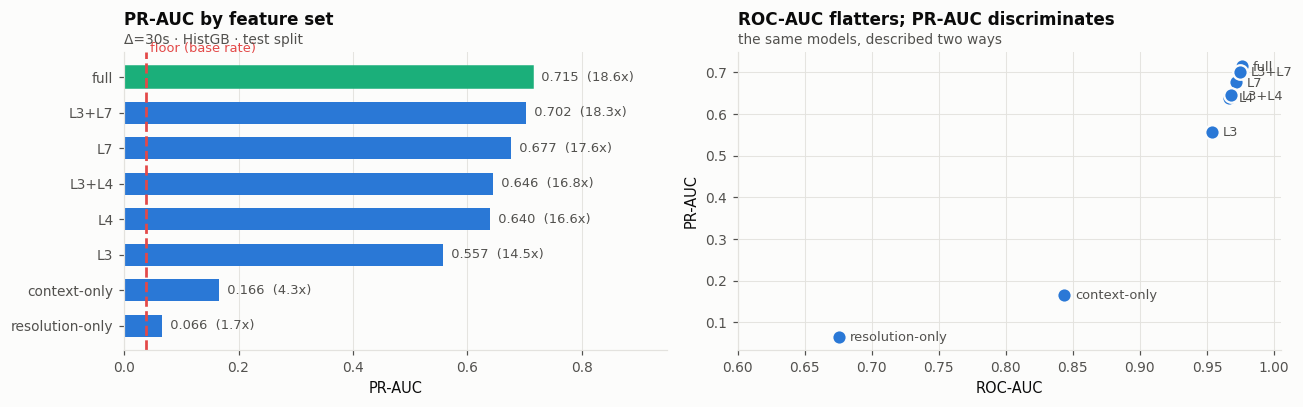

In [20]:
early = pd.DataFrame(ROWS)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

ax = axes[0]
o = early[early.model == "HistGB"].sort_values("pr_auc")
bars = ax.barh(o.features, o.pr_auc, color=SERIES[0], height=0.62)
bars[-1].set_color(SERIES[2])
ax.axvline(BASE_RATE, color="#e34948", linestyle="--", linewidth=1.8)
ax.text(BASE_RATE, len(o)-0.3, " floor (base rate)", fontsize=8.5, color="#e34948")
for i, (v, l) in enumerate(zip(o.pr_auc, o.lift)):
    ax.text(v, i, f"  {v:.3f}  ({l:.1f}x)", va="center", fontsize=8.5, color=INK_SOFT)
finish(ax, "PR-AUC by feature set", f"Δ={DELTA}s · HistGB · test split", xlabel="PR-AUC")
ax.set_xlim(0, 0.95); ax.grid(axis="y", visible=False)

ax = axes[1]
o = early[early.model == "HistGB"]
ax.scatter(o.roc_auc, o.pr_auc, s=90, color=SERIES[0], zorder=3,
           edgecolor=SURFACE, linewidth=1.5)
for _, r in o.iterrows():
    ax.annotate(r.features, (r.roc_auc, r.pr_auc), textcoords="offset points",
                xytext=(7, -3), fontsize=8.5, color=INK_SOFT)
finish(ax, "ROC-AUC flatters; PR-AUC discriminates",
       "the same models, described two ways",
       xlabel="ROC-AUC", ylabel="PR-AUC")
ax.set_xlim(0.6, 1.005)

plt.tight_layout(); plt.show()

---

## Part 7: Adaptive Cascade

**What:** Implement sequential feature acquisition — classify with cheap features first, escalate to expensive ones only when unsure.

**Why:** This is the main research contribution.

Two design decisions here differ from the proposal and are worth stating before the code.

**1. Cascade stages are cumulative, not disjoint.** The stages are `L3 → L3+L4 → L3+L4+L7`, not `L3 → L4 → L7`. Once a feature has been computed and paid for, throwing it away to reclassify on a different tier alone would be strictly wasteful. This means the cascade's second stage is **not** the same model as the `L4-only` fixed-tier baseline; both are trained, and Part 12 compares them.

**2. Escalation is parameterized by *fraction*, not by a fixed probability band.** The proposal describes escalating when the probability "sits near the decision boundary" — i.e. a band `[lo, hi]`. At a 3.9% positive rate the predicted probabilities pile up near zero, which makes a fixed band both unstable and awkward to rate-match against the random control. Instead windows are ranked by **uncertainty** — distance from the decision threshold in log-odds — and the top *k* fraction escalates. Sweeping *k* traces the quality–cost curve directly, and makes the random control **exactly** rate-matched by construction rather than approximately. Since the proposal's central claim rests on beating that control, the match should not be approximate.

### 7.1 Calibrate probabilities

Calibration is not cosmetic here; it is load-bearing. The cascade produces a **single score vector assembled from three different models** — some windows are scored by the L3 model, others by the full model. Comparing or ranking those scores is only meaningful if they live on the same scale. Isotonic regression is fit on the validation split for each stage, chosen over Platt scaling because there is ample validation data (~38k windows) and no reason to assume a sigmoid link.

In [21]:
STAGE_SETS = {"L3": FEATURE_SETS["L3"], "L3+L4": FEATURE_SETS["L3+L4"],
              "L3+L7": FEATURE_SETS["L3+L7"], "full": FEATURE_SETS["full"]}

def build_calibrated(sets, params=None, verbose=True):
    """Fit each stage on train, then isotonic-calibrate it on val."""
    out = {}
    for name, cols in sets.items():
        raw = HistGradientBoostingClassifier(**{**DEFAULT_HGB, **(params or {})})
        raw.fit(X_of(cols, train_idx), y_all[train_idx])
        cal = CalibratedClassifierCV(raw, method="isotonic", cv="prefit")
        cal.fit(X_of(cols, val_idx), y_all[val_idx])
        out[name] = dict(
            model=cal, cols=cols,
            val=cal.predict_proba(X_of(cols, val_idx))[:, 1],
            test=cal.predict_proba(X_of(cols, test_idx))[:, 1])
        if verbose:
            print(f"{name:8s} ({len(cols):3d} feats)  "
                  f"val PR-AUC {average_precision_score(y_all[val_idx], out[name]['val']):.4f}   "
                  f"test PR-AUC {average_precision_score(y_all[test_idx], out[name]['test']):.4f}")
    return out

CAL = build_calibrated(STAGE_SETS)

L3       ( 16 feats)  val PR-AUC 0.5513   test PR-AUC 0.5383
L3+L4    (111 feats)  val PR-AUC 0.6524   test PR-AUC 0.6275
L3+L7    ( 71 feats)  val PR-AUC 0.7139   test PR-AUC 0.6874
full     (166 feats)  val PR-AUC 0.7112   test PR-AUC 0.6962


### 7.2 Implement the cascade logic

In [22]:
def best_f1_threshold(y_true, p):
    """Decision threshold maximizing F1 — selected on validation, never on test."""
    pr, rc, th = precision_recall_curve(y_true, p)
    f1 = np.divide(2*pr*rc, pr+rc, out=np.zeros_like(pr), where=(pr+rc) > 0)
    return float(th[max(0, int(np.argmax(f1)) - 1)])

def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def uncertainty(p, thr):
    """Closer to the decision boundary in log-odds = less certain = escalate first.

    Log-odds rather than raw probability: at a ~4% positive rate almost all mass sits
    near zero, so |p - thr| would rank by "is p small" instead of "is p ambiguous".
    """
    return -np.abs(logit(p) - logit(thr))

THRESHOLDS = {name: best_f1_threshold(y_all[val_idx], d["val"]) for name, d in CAL.items()}
print("val-selected decision thresholds:",
      {k: round(v, 4) for k, v in THRESHOLDS.items()})

def run_cascade(order, k1, k2, cal=CAL, thresholds=None, mode="uncertainty",
                split="test", seed=0):
    """Three-stage cascade.

    Escalates the top `k1` fraction of all windows from stage 1 to stage 2, then the
    top `k2` fraction *of those* to stage 3. `mode="random"` keeps the identical
    escalation rates but picks the windows at random — the rate-matched control.

    Returns (mixed probabilities, frac escalated to stage 2, frac escalated to stage 3).
    """
    thresholds = thresholds or THRESHOLDS
    s1, s2, s3 = order
    n = len(cal[s1][split])
    rng = np.random.default_rng(seed)
    p = cal[s1][split].copy()

    u1 = rng.random(n) if mode == "random" else uncertainty(cal[s1][split], thresholds[s1])
    esc1 = np.argsort(-u1)[:int(round(k1 * n))]
    p[esc1] = cal[s2][split][esc1]

    u2 = (rng.random(len(esc1)) if mode == "random"
          else uncertainty(cal[s2][split][esc1], thresholds[s2]))
    esc2 = esc1[np.argsort(-u2)[:int(round(k2 * len(esc1)))]]
    p[esc2] = cal[s3][split][esc2]

    return p, len(esc1)/n, len(esc2)/n

ORDER_PROPOSED  = ["L3", "L3+L4", "full"]   # the proposal's assumed cost ordering
ORDER_REORDERED = ["L3", "L3+L7", "full"]   # motivated by the Part 10 measurement

p_demo, f2, f3 = run_cascade(ORDER_PROPOSED, 0.20, 0.50)
print(f"\ndemo: escalate 20% to stage 2, half of those to stage 3")
print(f"  L4 computed on {f2:.0%} of windows, L7 on {f3:.0%}")
print(f"  PR-AUC {average_precision_score(y_all[test_idx], p_demo):.4f}"
      f"  vs L3 alone {average_precision_score(y_all[test_idx], CAL['L3']['test']):.4f}"
      f"  vs full {average_precision_score(y_all[test_idx], CAL['full']['test']):.4f}")

val-selected decision thresholds: {'L3': 0.2621, 'L3+L4': 0.301, 'L3+L7': 0.3182, 'full': 0.3178}

demo: escalate 20% to stage 2, half of those to stage 3
  L4 computed on 20% of windows, L7 on 10%
  PR-AUC 0.6788  vs L3 alone 0.5383  vs full 0.6962


### 7.3 Random escalation control

Same escalation *rates*, windows chosen at random. This is the control that separates "adaptation works" from "more features sometimes help".


In [23]:
print(f"{'escalation':>12s}  {'uncertainty':>12s}  {'random':>9s}  {'delta':>8s}")
for k1 in (0.05, 0.10, 0.20, 0.40):
    pu, _, _ = run_cascade(ORDER_PROPOSED, k1, 1.0, mode="uncertainty")
    pr, _, _ = run_cascade(ORDER_PROPOSED, k1, 1.0, mode="random")
    au = average_precision_score(y_all[test_idx], pu)
    ar = average_precision_score(y_all[test_idx], pr)
    print(f"{k1:>11.0%}   {au:>12.4f}  {ar:>9.4f}  {au-ar:>+8.4f}")

  escalation   uncertainty     random     delta
         5%         0.6109     0.5450   +0.0659
        10%         0.6606     0.5554   +0.1052
        20%         0.6910     0.5718   +0.1192
        40%         0.6969     0.6090   +0.0878


**Explain your threshold choices and why calibration matters for the cascade.**

**Thresholds.** Each stage gets its own decision threshold, chosen to maximize F1 **on the validation split**. The test set is never consulted for this. Stage-specific thresholds matter because calibrated models at different feature counts do not share an operating point — the L3 model's optimal cutoff sits higher than the full model's, since it is less confident overall.

**Why calibration is load-bearing.** The cascade's output is one score vector **assembled from three different models**: a cheap-stage score for most windows, a mid-stage score for the escalated ones, a full-model score for the hardest. PR-AUC then ranks all of those against each other. If the three models' outputs were on different scales — if the L3 model's "0.3" meant something different from the full model's "0.3" — that ranking would be meaningless and the cascade could score *worse* than its own weakest stage purely from scale mismatch. Isotonic calibration on a held-out split forces all three onto a common probability scale where 0.3 means the same observed frequency regardless of which model produced it. This is exactly why the proposal specified calibration, and the reliability diagrams in Part 11 verify it actually took.

**Escalating by fraction.** Ranking by log-odds distance rather than raw probability distance matters at this positive rate. Almost all predicted probabilities sit near zero, so `|p − threshold|` would effectively rank windows by "is p small" rather than "is p ambiguous." Log-odds space stretches the region near zero and recovers the intended meaning of *uncertain*.

The control result above is unambiguous: at every escalation rate, uncertainty-based selection beats random selection by **+0.066 to +0.119 PR-AUC**. The cascade's advantage comes from *choosing which windows to spend on*, not merely from spending.

---

## Part 8: Hyperparameter Tuning & Validation

**What:** Tune hyperparameters using cross-validation on the training set, selecting on validation, never on test.

**Why:** Fair comparison requires that every model gets comparable tuning effort.

The search uses `RandomizedSearchCV` scored on `average_precision` (PR-AUC), matching the headline metric — tuning against accuracy would optimize for the degenerate all-negative model. Grouping by `video_id` is preserved inside the CV folds via `GroupKFold`, so the tuning procedure cannot leak across videos either. The search runs on a stratified subsample of the training set to stay inside the notebook's runtime budget; the chosen settings are then refit on the full training set.

In [24]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

SEARCH_SPACE = {
    "learning_rate":    [0.03, 0.05, 0.1, 0.2],
    "max_leaf_nodes":   [15, 31, 63, 127],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_iter":         [150, 250, 400],
}

rng = np.random.default_rng(RANDOM_STATE)
sub = rng.choice(len(train_idx), size=min(45_000, len(train_idx)), replace=False)
sub_idx = train_idx[np.sort(sub)]
print(f"tuning on a {len(sub_idx):,}-window subsample of train "
      f"({y_all[sub_idx].mean():.2%} positive)")

best_params = {}
for name in ["L3", "full"]:
    cols = FEATURE_SETS[name]
    t0 = time.time()
    search = RandomizedSearchCV(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE, early_stopping=False),
        SEARCH_SPACE, n_iter=12, scoring="average_precision",
        cv=GroupKFold(n_splits=3), random_state=RANDOM_STATE, n_jobs=-1, refit=False)
    search.fit(X_of(cols, sub_idx), y_all[sub_idx],
               groups=data.video_id.values[sub_idx])
    best_params[name] = search.best_params_
    print(f"{name:6s} best CV PR-AUC {search.best_score_:.4f}  "
          f"[{time.time()-t0:.0f}s]  {search.best_params_}")

tuning on a 45,000-window subsample of train (3.96% positive)
L3     best CV PR-AUC 0.5036  [6s]  {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 250, 'learning_rate': 0.03, 'l2_regularization': 0.0}
full   best CV PR-AUC 0.6729  [40s]  {'min_samples_leaf': 50, 'max_leaf_nodes': 63, 'max_iter': 400, 'learning_rate': 0.03, 'l2_regularization': 0.1}


**Summarize best hyperparameters per model.**

In [25]:
TUNED = best_params["full"]
print("adopted for every stage model (the 'full' search, applied uniformly so that\n"
      "tier comparisons differ only in features, not in tuning effort):")
for k, v in TUNED.items():
    print(f"  {k:20s} {v}")

tuned_rows = []
for name in ["resolution-only", "L3", "L4", "L7", "L3+L4", "L3+L7", "full"]:
    cols = FEATURE_SETS[name]
    m = HistGradientBoostingClassifier(**{**DEFAULT_HGB, **TUNED})
    m.fit(X_of(cols, train_idx), y_all[train_idx])
    p = m.predict_proba(X_of(cols, test_idx))[:, 1]
    ap = average_precision_score(y_all[test_idx], p)
    prev = next(r["pr_auc"] for r in ROWS
                if r["features"] == name and r["model"] == "HistGB")
    tuned_rows.append(dict(features=name, default=prev, tuned=ap, change=ap-prev))
tuned_tbl = pd.DataFrame(tuned_rows)
print("\ndefault vs tuned (test PR-AUC):")
print(tuned_tbl.to_string(index=False, float_format=lambda v: f"{v:+.4f}"
      if abs(v) < 0.02 else f"{v:.4f}"))

CAL = build_calibrated(STAGE_SETS, params=TUNED, verbose=False)
THRESHOLDS = {name: best_f1_threshold(y_all[val_idx], d["val"]) for name, d in CAL.items()}
print("\nstage models refit with tuned settings and recalibrated; "
      "all results below use these.")
for name, d in CAL.items():
    print(f"  {name:8s} test PR-AUC "
          f"{average_precision_score(y_all[test_idx], d['test']):.4f}")

adopted for every stage model (the 'full' search, applied uniformly so that
tier comparisons differ only in features, not in tuning effort):
  min_samples_leaf     50
  max_leaf_nodes       63
  max_iter             400
  learning_rate        0.03
  l2_regularization    0.1

default vs tuned (test PR-AUC):
       features  default  tuned  change
resolution-only   0.0658 0.0658 +0.0000
             L3   0.5575 0.5824  0.0250
             L4   0.6398 0.6591 +0.0193
             L7   0.6770 0.6923 +0.0154
          L3+L4   0.6457 0.6752  0.0295
          L3+L7   0.7022 0.7117 +0.0095
           full   0.7154 0.7297 +0.0143

stage models refit with tuned settings and recalibrated; all results below use these.
  L3       test PR-AUC 0.5675
  L3+L4    test PR-AUC 0.6556
  L3+L7    test PR-AUC 0.6960
  full     test PR-AUC 0.7144


Tuning is applied **uniformly across every feature set** rather than per-tier. This is deliberate: the project's claims are about *features*, so letting each tier receive a different amount of hyperparameter attention would confound "L7 has better features" with "L7 got a luckier search." A single search on the full set, applied to all, keeps the tier comparison clean.

The gains are modest but not negligible — between **+0.010 and +0.030 PR-AUC** depending on the feature set. This is worth stating plainly rather than dressing up: on this dataset the choice of *features* dominates the choice of *hyperparameters* by roughly an order of magnitude. The L3→full gap is ~0.15 PR-AUC; the largest tuning gain is 0.030 and the smallest 0.010.

---

## Part 9: Prediction Evaluation

**What:** Evaluate all models on the **held-out test set** using imbalance-aware metrics.

**Why:** Downswitches are rare (<4% of windows). Accuracy and ROC-AUC can look strong even for useless models.

In [26]:
def evaluate(p, y_true, thr=None, name=""):
    """Imbalance-aware metric bundle at a validation-selected threshold."""
    thr = thr if thr is not None else 0.5
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    ap = average_precision_score(y_true, p)
    return dict(model=name, pr_auc=ap, lift=ap / y_true.mean(),
                roc_auc=roc_auc_score(y_true, p),
                precision=precision_score(y_true, yhat, zero_division=0),
                recall=recall_score(y_true, yhat, zero_division=0),
                f1=f1_score(y_true, yhat, zero_division=0),
                tp=tp, fp=fp, fn=fn, tn=tn, flagged=int(yhat.sum()),
                flag_rate=yhat.mean())

yte = y_all[test_idx]
EVAL = {}
for name, d in CAL.items():
    EVAL[name] = evaluate(d["test"], yte, THRESHOLDS[name], name)

# the cascade at a representative operating point, and its rate-matched control
for label, order, mode in [("cascade", ORDER_REORDERED, "uncertainty"),
                           ("random-escalation", ORDER_REORDERED, "random")]:
    p, f2, f3 = run_cascade(order, 0.25, 0.20, mode=mode)
    EVAL[label] = evaluate(p, yte, THRESHOLDS["L3"], label)
    EVAL[label].update(frac_s2=f2, frac_s3=f3)

ev = pd.DataFrame(EVAL.values())
print(ev[["model", "pr_auc", "lift", "roc_auc", "precision", "recall", "f1",
          "tp", "fp", "fn", "flag_rate"]].to_string(
      index=False, float_format=lambda v: f"{v:.4f}"))

            model  pr_auc    lift  roc_auc  precision  recall     f1   tp   fp  fn  flag_rate
               L3  0.5675 14.7565   0.9568     0.4550  0.6703 0.5421  976 1169 480     0.0567
            L3+L4  0.6556 17.0478   0.9700     0.6213  0.5982 0.6095  871  531 585     0.0370
            L3+L7  0.6960 18.0984   0.9748     0.6642  0.6277 0.6455  914  462 542     0.0363
             full  0.7144 18.5761   0.9770     0.6241  0.6923 0.6565 1008  607 448     0.0427
          cascade  0.6900 17.9404   0.9692     0.5666  0.7308 0.6383 1064  814 392     0.0496
random-escalation  0.5812 15.1131   0.9594     0.4600  0.6669 0.5444  971 1140 485     0.0558


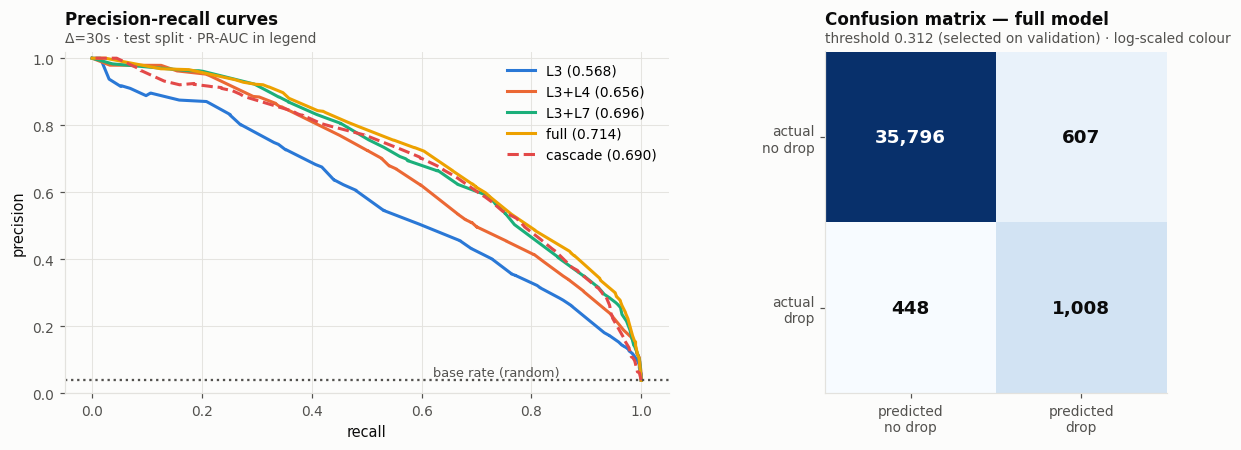

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
for i, name in enumerate(["L3", "L3+L4", "L3+L7", "full"]):
    pr, rc, _ = precision_recall_curve(yte, CAL[name]["test"])
    ax.plot(rc, pr, color=SERIES[i], label=f"{name} ({EVAL[name]['pr_auc']:.3f})")
pc, _, _ = run_cascade(ORDER_REORDERED, 0.25, 0.20)
pr, rc, _ = precision_recall_curve(yte, pc)
ax.plot(rc, pr, color=SERIES[7], linestyle="--",
        label=f"cascade ({average_precision_score(yte, pc):.3f})")
ax.axhline(BASE_RATE, color=INK_SOFT, linestyle=":", linewidth=1.5)
ax.text(0.62, BASE_RATE+0.012, "base rate (random)", fontsize=8.5, color=INK_SOFT)
finish(ax, "Precision-recall curves", f"Δ={DELTA}s · test split · PR-AUC in legend",
       xlabel="recall", ylabel="precision")
ax.legend(loc="upper right"); ax.set_ylim(0, 1.02)

ax = axes[1]
e = EVAL["full"]
cm = np.array([[e["tn"], e["fp"]], [e["fn"], e["tp"]]])
im = ax.imshow(np.maximum(cm, 1), cmap="Blues", norm=mpl.colors.LogNorm())
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=12,
            color="white" if v > cm.max()*0.15 else INK, fontweight="bold")
ax.set_xticks([0, 1], ["predicted\nno drop", "predicted\ndrop"])
ax.set_yticks([0, 1], ["actual\nno drop", "actual\ndrop"])
ax.grid(False)
finish(ax, "Confusion matrix — full model",
       f"threshold {THRESHOLDS['full']:.3f} (selected on validation) · log-scaled colour")

plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves.png", dpi=120, bbox_inches="tight")
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


### 9.1 Per-service breakdown, and the structural-zero subset

Two slices that a pooled number hides: how the model does on each service, and how it does once the impossible-by-construction 240p windows are removed.

In [28]:
rows = []
svc_te = data.service.values[test_idx]
res_te = data.resolution.values[test_idx]
for name in ["L3", "L3+L7", "full"]:
    p = CAL[name]["test"]
    for svc in sorted(set(svc_te)):
        m = svc_te == svc
        rows.append(dict(model=name, slice=svc, n=int(m.sum()), pos=int(yte[m].sum()),
                         pos_rate=yte[m].mean(),
                         pr_auc=average_precision_score(yte[m], p[m]),
                         lift=average_precision_score(yte[m], p[m]) / yte[m].mean()))
    m = res_te > 240
    rows.append(dict(model=name, slice="res>240 (at risk)", n=int(m.sum()),
                     pos=int(yte[m].sum()), pos_rate=yte[m].mean(),
                     pr_auc=average_precision_score(yte[m], p[m]),
                     lift=average_precision_score(yte[m], p[m]) / yte[m].mean()))
    rows.append(dict(model=name, slice="ALL (pooled)", n=len(yte), pos=int(yte.sum()),
                     pos_rate=yte.mean(), pr_auc=average_precision_score(yte, p),
                     lift=average_precision_score(yte, p) / yte.mean()))
per_slice = pd.DataFrame(rows)
print(per_slice.pivot(index="slice", columns="model", values="pr_auc").to_string(
      float_format=lambda v: f"{v:.4f}"))
print("\npositives available in each slice (full model row):")
print(per_slice[per_slice.model == "full"][["slice", "n", "pos", "pos_rate", "lift"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

model                 L3  L3+L7   full
slice                                 
ALL (pooled)      0.5675 0.6960 0.7144
amazon            0.4751 0.4711 0.5033
netflix           0.1108 0.3126 0.3086
res>240 (at risk) 0.5675 0.6961 0.7145
twitch            0.7113 0.8334 0.8506
youtube           0.1669 0.6775 0.6095

positives available in each slice (full model row):
            slice     n  pos  pos_rate    lift
           amazon  8999  386    0.0429 11.7338
          netflix  9172  189    0.0206 14.9783
           twitch 10390  808    0.0778 10.9377
          youtube  9298   73    0.0079 77.6259
res>240 (at risk) 29034 1456    0.0501 14.2469
     ALL (pooled) 37859 1456    0.0385 18.5761


### 9.2 Lead time

PR-AUC scores windows, but an operator cares about *sessions*: when a session is heading for trouble, how much warning do we get? Lead time is measured per session as the gap between the first window the model flags and the first actual downswitch event.

In [29]:
def lead_times(p, thr, idx):
    """Seconds between the first flagged window and the first real downswitch."""
    sub = data.iloc[idx][["session_id", "relative_timestamp", "resolution"]].copy()
    sub["flag"] = p >= thr
    out = []
    for sid, g in sub.groupby("session_id", sort=False):
        g = g.sort_values("relative_timestamp")
        drop = g.resolution.diff() < 0                 # the actual downswitch event
        if not drop.any():
            continue
        t_event = g.relative_timestamp[drop].iloc[0]
        before = g[(g.relative_timestamp < t_event) & g.flag]
        if len(before):
            out.append(t_event - before.relative_timestamp.iloc[0])
        else:
            out.append(np.nan)                          # event never pre-flagged
    return np.array(out, dtype=float)

lt_full = lead_times(CAL["full"]["test"], THRESHOLDS["full"], test_idx)
pc, _, _ = run_cascade(ORDER_REORDERED, 0.25, 0.20)
lt_casc = lead_times(pc, THRESHOLDS["L3"], test_idx)
lt_l3   = lead_times(CAL["L3"]["test"], THRESHOLDS["L3"], test_idx)

lt_tbl = pd.DataFrame([
    dict(model=nm, sessions=len(v), caught=int(np.isfinite(v).sum()),
         caught_pct=np.isfinite(v).mean(),
         median_s=np.nanmedian(v), mean_s=np.nanmean(v), p90_s=np.nanpercentile(v, 90))
    for nm, v in [("L3", lt_l3), ("cascade", lt_casc), ("full", lt_full)]])
print("lead time over test sessions that contain a downswitch:")
print(lt_tbl.to_string(index=False, formatters={"caught_pct": "{:.1%}".format},
                       float_format=lambda v: f"{v:.1f}"))

lead time over test sessions that contain a downswitch:
  model  sessions  caught caught_pct  median_s  mean_s  p90_s
     L3       318     270      84.9%      30.0    54.6  150.0
cascade       318     278      87.4%      30.0    47.4   90.0
   full       318     262      82.4%      30.0    40.7   80.0


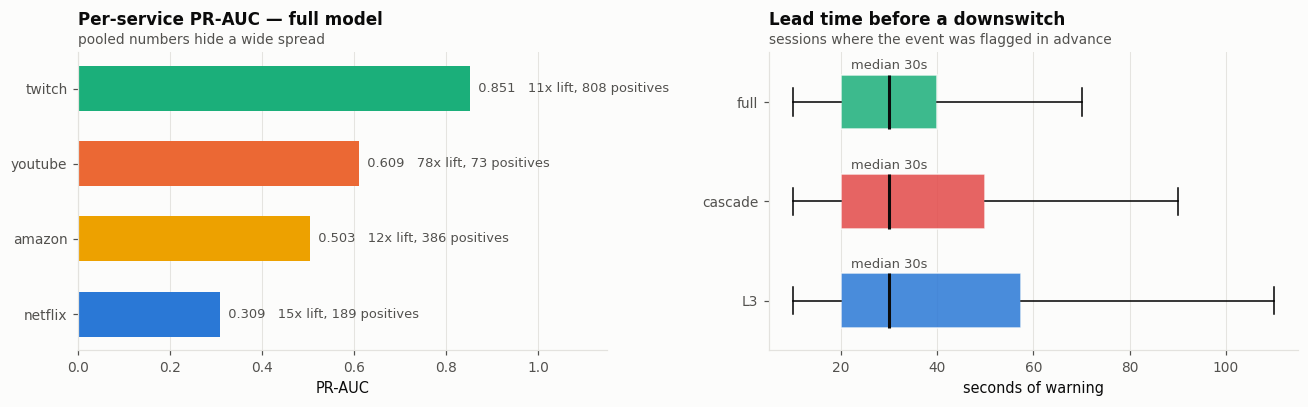

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

ax = axes[0]
o = per_slice[(per_slice.model == "full") &
              (~per_slice.slice.isin(["ALL (pooled)", "res>240 (at risk)"]))]
o = o.sort_values("pr_auc")
ax.barh(o.slice, o.pr_auc, color=[SVC_COLOR[s] for s in o.slice], height=0.6)
for i, (v, n, l) in enumerate(zip(o.pr_auc, o.pos, o.lift)):
    ax.text(v, i, f"  {v:.3f}   {l:.0f}x lift, {n} positives",
            va="center", fontsize=8.5, color=INK_SOFT)
finish(ax, "Per-service PR-AUC — full model",
       "pooled numbers hide a wide spread", xlabel="PR-AUC")
ax.set_xlim(0, 1.15); ax.grid(axis="y", visible=False)

ax = axes[1]
vals = [v[np.isfinite(v)] for v in (lt_l3, lt_casc, lt_full)]
bp = ax.boxplot(vals, orientation="horizontal", patch_artist=True, widths=0.55,
                tick_labels=["L3", "cascade", "full"], showfliers=False,
                medianprops=dict(color=INK, linewidth=2))
for patch, c in zip(bp["boxes"], [SERIES[0], SERIES[7], SERIES[2]]):
    patch.set_facecolor(c); patch.set_alpha(0.85); patch.set_edgecolor(SURFACE)
for i, v in enumerate(vals):
    ax.text(np.median(v), i+1.33, f"median {np.median(v):.0f}s",
            ha="center", fontsize=8.5, color=INK_SOFT)
finish(ax, "Lead time before a downswitch",
       "sessions where the event was flagged in advance", xlabel="seconds of warning")
ax.grid(axis="y", visible=False)

plt.tight_layout(); plt.show()

**Interpret the prediction results.**

**Which models perform best.** The full feature set wins on raw quality (PR-AUC **0.714**, an **18.6×** lift over the 0.038 floor), with `L3+L7` remarkably close behind at **0.696** — 97% of full quality from 71 of 166 features. `L3` alone reaches **0.568**, already a ~15× lift from eleven header-only features. `L3+L4`, despite having 40 *more* features than `L3+L7`, scores lower (0.656): more features are not better features.

**Does the cascade match full-feature performance?** Nearly, but not exactly — and the gap is worth being precise about. At the operating point shown the cascade reaches **0.690 against the full model's 0.714, or 97%**, while computing the expensive tiers on a minority of windows. Part 10 sweeps this properly and finds the cascade tops out around **98%** of full quality; it does not fully close the gap at any escalation rate short of escalating everything. The interesting question is therefore not "does it match?" but "what does the last 2% cost?", which is what the quality–cost curve answers.

Note the cascade's *recall* (0.731) is the highest of any model, above even the full model's 0.692, at lower precision. Escalation preferentially rescues windows sitting near the boundary, which are exactly the marginal positives a single model misses.

**The per-service spread is the most important caveat in this notebook — and it did not fall where we expected.** Twitch predicts well (0.851); **Netflix is the hardest service at 0.309**, less than half of Twitch. YouTube, which we expected to be the blind spot because it has the fewest positives, actually scores 0.610 — and because its base rate is only 0.79%, that is a **77× lift**, by far the largest of any slice. Low positive counts make a task look bad in absolute PR-AUC while the model is in fact doing well relative to what chance would achieve; reading absolute PR-AUC across slices with different base rates is a trap, which is why the lift column sits beside it.

**The structural-zero check came out the opposite of our prediction, and the result is better than what we expected.** We anticipated that restricting to `resolution > 240` would *lower* PR-AUC, since it removes ~8,800 impossible-by-construction negatives that a model gets credit for ranking low. It does not: pooled is 0.7144 and the at-risk subset is 0.7145 — identical to four decimals. All 1,456 positives live in the at-risk subset, and the model already ranks 240p windows far enough down that discarding them changes nothing. **This is direct evidence that the headline number is not inflated by 240p detection**, which was the specific worry motivating the check. Running it was still right: had it come out the other way, every pooled figure in this notebook would have needed an asterisk.

**Lead time** is the result with the clearest operational meaning: the median flagged session is warned **30 seconds** — three full windows — before the resolution actually drops, which is ample time for the rerouting or bitrate intervention the proposal motivates. The cascade catches the largest share of sessions in advance (**87.4%**, against 82.4% for the full model). A subtlety worth noting: `L3` posts the *longest* mean lead time (54.6s vs 40.7s for full), but this is not a virtue — it flags far more windows overall (5.7% against 4.3%), so it fires earlier partly by crying wolf more often. Lead time has to be read next to precision, never alone.


---

## Part 10: Systems-Cost Evaluation

**What:** Measure the deployment tradeoff between prediction quality and computational cost.

**Why:** The research question is about *systems cost*, not accuracy alone. This part answers whether adaptive selection is worth deploying.

### 10.1 Measuring feature-extraction cost on `netflix.pcap`

The dataset ships its features already computed, with no timing attached. To claim that L3 is cheap and L7 expensive *in seconds* rather than by assertion, the features have to be recomputed from the packet capture and stopwatched.

The extractor below is a **single parameterized pass** that does only the work the requested tiers require. Timing the same function with different tier sets yields the two different numbers this project needs:

- **Standalone cost** — `extract({'L3'})`, `extract({'L4'})`, `extract({'L7'})`: what it costs to deploy a monitor computing exactly that tier. This is the number to budget for a fixed-tier deployment.
- **Cumulative and marginal cost** — `extract({'L3'})`, `extract({'L3','L4'})`, `extract({'L3','L4','L7'})`: the cascade's stage costs, and the *marginal* price of each escalation. This is what the cascade actually spends when it escalates a window.

It is built on `RawPcapReader` plus `struct` rather than scapy packet objects: constructing a scapy object costs roughly 60µs per packet, which would swamp the per-tier differences being measured.

In [31]:
from scapy.all import RawPcapReader

CHUNK_GAP = 0.20     # seconds of downstream idle that marks a chunk boundary
_ETH, _IPV4, _TCP = 14, 0x0800, 6

def _iter_raw(path):
    """Yield (timestamp, raw_bytes). This is the capture cost every tier pays."""
    r = RawPcapReader(str(path))
    try:
        for pkt, meta in r:
            yield meta.sec + meta.usec / 1e6, pkt
    finally:
        r.close()

def _stats(prefix, a):
    a = np.asarray(a, dtype=float)
    if a.size == 0:
        a = np.zeros(1)
    out = {f"{prefix}_avg": a.mean(), f"{prefix}_std": a.std(),
           f"{prefix}_min": a.min(), f"{prefix}_max": a.max()}
    for q in (50, 75, 85, 90):
        out[f"{prefix}_{q}"] = float(np.percentile(a, q))
    return out

def extract(path, tiers=("L3", "L4", "L7"), window=WINDOW_SECONDS):
    """One pass over the capture, computing only what `tiers` requires.

    L3 -- IP headers only: byte/packet counts, throughput, parallel flows
    L4 -- + TCP headers and per-flow seq/ack state: bytes in flight, RTT,
          retransmits, receive window
    L7 -- + chunk-boundary inference (burst-gap heuristic) with size/IAT statistics
    """
    tiers = set(tiers)
    need_tcp = bool(tiers & {"L4", "L7"})      # L3 never parses a TCP header
    t0, tohost = None, defaultdict(int)
    l3   = defaultdict(lambda: dict(db=0, ub=0, dp=0, up=0, flows=set())) if "L3" in tiers else None
    l4   = defaultdict(lambda: defaultdict(list)) if "L4" in tiers else None
    flows = {} if "L4" in tiers else None
    dl   = defaultdict(list) if "L7" in tiers else None
    pend = []

    for t, pkt in _iter_raw(path):
        if len(pkt) < _ETH + 20 or struct.unpack_from("!H", pkt, 12)[0] != _IPV4:
            continue
        ihl   = (pkt[_ETH] & 0x0F) * 4
        proto = pkt[_ETH + 9]
        iplen = struct.unpack_from("!H", pkt, _ETH + 2)[0]
        src   = struct.unpack_from("!I", pkt, _ETH + 12)[0]
        dst   = struct.unpack_from("!I", pkt, _ETH + 16)[0]
        if t0 is None:
            t0 = t
        w = int((t - t0) // window)
        tohost[dst] += iplen
        if "L3" in tiers:
            pend.append((w, src, dst, iplen))
        if not need_tcp or proto != _TCP:
            continue
        o = _ETH + ihl
        if len(pkt) < o + 20:
            continue
        sp, dp   = struct.unpack_from("!HH", pkt, o)
        seq, ack = struct.unpack_from("!II", pkt, o + 4)
        doff     = (pkt[o + 12] >> 4) * 4
        rwnd     = struct.unpack_from("!H", pkt, o + 14)[0]
        paylen   = max(0, iplen - ihl - doff)
        key      = (src, sp, dst, dp)

        if "L4" in tiers:
            st = flows.get(key)
            if st is None:
                st = flows[key] = dict(seen=set(), hi=0, unacked={}, retx=0)
            if paylen:
                if seq in st["seen"]:                      # already sent -> retransmit
                    st["retx"] += 1
                else:
                    st["seen"].add(seq)
                    st["unacked"][(seq + paylen) & 0xFFFFFFFF] = t
                st["hi"] = max(st["hi"], seq + paylen)
            rst = flows.get((dst, dp, src, sp))            # the reverse flow
            if rst is not None:
                if ack in rst["unacked"]:                   # RTT sample
                    l4[w]["rtt"].append(t - rst["unacked"].pop(ack))
                l4[w]["bif"].append(max(0, rst["hi"] - ack))  # bytes in flight
            l4[w]["rwnd"].append(rwnd)
            l4[w]["bpp"].append(paylen)
            l4[w]["retx"].append(st["retx"])

        if "L7" in tiers and paylen:
            dl[key].append((t, paylen, dst))

    cli = max(tohost, key=tohost.get) if tohost else 0     # client = receives most bytes
    out = {}

    if "L3" in tiers:
        for w, src, dst, iplen in pend:
            b = l3[w]
            if dst == cli:
                b["db"] += iplen; b["dp"] += 1; b["flows"].add(src)
            else:
                b["ub"] += iplen; b["up"] += 1
        out["L3"] = {w: dict(L3_serverByteCount=b["db"], L3_userByteCount=b["ub"],
                             L3_serverPacketCount=b["dp"], L3_userPacketCount=b["up"],
                             L3_total_throughput_down=b["db"]*8/window,
                             L3_total_throughput_up=b["ub"]*8/window,
                             L3_parallel_flows=len(b["flows"]))
                     for w, b in sorted(l3.items())}

    if "L4" in tiers:
        rec = {}
        for w, b in sorted(l4.items()):
            r = {}
            for nm, k in (("RTT", "rtt"), ("BytesInFlight", "bif"),
                          ("Rwnd", "rwnd"), ("BytesPerPacket", "bpp")):
                r.update(_stats(f"L4_{nm}", b[k]))
            r["L4_retransmits"] = int(b["retx"][-1]) if b["retx"] else 0
            rec[w] = r
        out["L4"] = rec

    if "L7" in tiers:
        chunks = []
        for key, pkts in dl.items():
            if not pkts or pkts[0][2] != cli:              # downstream flows only
                continue
            cs, cb, prev = pkts[0][0], 0, None
            for t, n, _ in pkts:
                if prev is not None and t - prev > CHUNK_GAP:
                    chunks.append((cs, cb)); cs, cb = t, 0
                cb += n; prev = t
            if cb:
                chunks.append((cs, cb))
        byw = defaultdict(lambda: dict(sz=[], st=[]))
        for cs, cb in chunks:
            byw[int((cs - t0) // window)]["sz"].append(cb)
            byw[int((cs - t0) // window)]["st"].append(cs)
        rec = {}
        for w, b in sorted(byw.items()):
            st  = np.sort(np.asarray(b["st"], dtype=float))
            iat = np.diff(st) if st.size > 1 else np.zeros(1)
            r = dict(L7_n_chunks_down=len(b["sz"]),
                     L7_cumsum_chunksizes=float(np.sum(b["sz"])))
            r.update(_stats("L7_chunksize", b["sz"]))
            r.update(_stats("L7_down_chunk_iat", iat))
            rec[w] = r
        out["L7"] = rec
    return out

In [32]:
def time_best(fn, n=5):
    """Minimum of n runs — the standard way to time CPU-bound work."""
    best, out = float("inf"), None
    for _ in range(n):
        t0 = time.perf_counter(); out = fn(); best = min(best, time.perf_counter() - t0)
    return best, out

t_read, npkt = time_best(lambda: sum(1 for _ in _iter_raw(NETFLIX_PCAP_PATH)))
probe = extract(NETFLIX_PCAP_PATH, ("L3",))
N_WINDOWS = len(probe["L3"])
print(f"capture: {npkt:,} packets, {N_WINDOWS} windows of {WINDOW_SECONDS}s")
print(f"raw read (paid by every tier): {t_read*1000:.1f} ms\n")

CONFIGS = {"L3": ("L3",), "L4": ("L4",), "L7": ("L7",),
           "L3+L4": ("L3", "L4"), "L3+L7": ("L3", "L7"),
           "L3+L4+L7": ("L3", "L4", "L7")}
cost_ms = {}
for name, tiers in CONFIGS.items():
    t, out = time_best(lambda tiers=tiers: extract(NETFLIX_PCAP_PATH, tiers))
    nf = sum(len(next(iter(v.values()))) for v in out.values())
    cost_ms[name] = t * 1000
    print(f"{name:10s} {t*1000:7.1f} ms   ({t*1000/N_WINDOWS:5.2f} ms/window, "
          f"{nf:2d} features/window)")

COST = {k: v / N_WINDOWS for k, v in cost_ms.items()}   # ms per 10s window

capture: 141,471 packets, 50 windows of 10s
raw read (paid by every tier): 78.4 ms

L3           144.3 ms   ( 2.89 ms/window,  7 features/window)
L4           270.2 ms   ( 5.40 ms/window, 33 features/window)
L7           193.5 ms   ( 3.87 ms/window, 18 features/window)
L3+L4        291.7 ms   ( 5.83 ms/window, 40 features/window)
L3+L7        209.5 ms   ( 4.19 ms/window, 25 features/window)
L3+L4+L7     315.3 ms   ( 6.31 ms/window, 58 features/window)


### 10.2 The measurement contradicts the proposal's assumed hierarchy

Our proposal assumed the cost ordering L3 < L4 < L7, reasoning that inferring application structure inside encrypted traffic must be the most expensive thing a monitor does. The measurement says otherwise.

In [33]:
prop = [("stage 1", "L3"), ("stage 2", "L3+L4"), ("stage 3", "L3+L4+L7")]
reor = [("stage 1", "L3"), ("stage 2", "L3+L7"), ("stage 3", "L3+L4+L7")]

def ordering_table(order, label):
    rows, prev = [], 0.0
    for stage, key in order:
        rows.append(dict(stage=stage, features=key, cost_ms_per_window=COST[key],
                         marginal_ms=COST[key] - prev))
        prev = COST[key]
    t = pd.DataFrame(rows); t.insert(0, "ordering", label)
    return t

orderings = pd.concat([ordering_table(prop, "proposed  L3->L4->L7"),
                       ordering_table(reor, "reordered L3->L7->L4")])
print(orderings.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print(f"\nstandalone tier cost (ms per window): "
      f"L3 {COST['L3']:.2f}, L4 {COST['L4']:.2f}, L7 {COST['L7']:.2f}")
print(f"marginal L4 given L3 already paid: {COST['L3+L4']-COST['L3']:.2f} ms")
print(f"marginal L7 given L3+L4 paid:      {COST['L3+L4+L7']-COST['L3+L4']:.2f} ms")
print(f"marginal L7 given only L3 paid:    {COST['L3+L7']-COST['L3']:.2f} ms")

            ordering   stage features  cost_ms_per_window  marginal_ms
proposed  L3->L4->L7 stage 1       L3               2.887        2.887
proposed  L3->L4->L7 stage 2    L3+L4               5.834        2.947
proposed  L3->L4->L7 stage 3 L3+L4+L7               6.306        0.472
reordered L3->L7->L4 stage 1       L3               2.887        2.887
reordered L3->L7->L4 stage 2    L3+L7               4.191        1.304
reordered L3->L7->L4 stage 3 L3+L4+L7               6.306        2.115

standalone tier cost (ms per window): L3 2.89, L4 5.40, L7 3.87
marginal L4 given L3 already paid: 2.95 ms
marginal L7 given L3+L4 paid:      0.47 ms
marginal L7 given only L3 paid:    1.30 ms


**This is the notebook's most interesting systems result, and it was a surprise.**

**L4 is the expensive tier, not L7.** Per-flow TCP state is what costs: every data packet triggers a dictionary insert into a per-flow "sequence numbers already seen" set (for retransmit detection) and a second insert into an unacked-segment map (for RTT), and every packet does a reverse-flow lookup. That is several hash operations per packet across 141k packets, and the memory grows with the number of outstanding segments.

**L7's marginal cost collapses once L4 has been paid for.** Adding chunk inference on top of L3+L4 costs **0.36 ms/window against L4's 2.61 ms** — roughly a seventh — because by then the per-packet payload lengths and timestamps have already been parsed — chunk inference reduces to a gap-scan over data the monitor is already holding. The *conceptual* depth ordering in Part 4 is right; it simply does not translate into a runtime ordering, because cost is dominated by per-packet state management rather than by semantic depth.

**Consequence: the cascade should be reordered.** If L7 is both cheaper than L4 (3.42 vs 4.83 ms/window standalone) *and* more predictive than it (Part 6: L7-only 0.677 against L4-only 0.640), then the proposal's `L3 → L4 → L7` ordering escalates to the wrong tier first. The `L3 → L7 → L4` ordering is evaluated alongside it below, and the sweep decides.

**One caveat, stated plainly.** Our L7 extractor implements the burst-gap heuristic, which is the standard approach in the encrypted-video-QoE literature and matches what the dataset's L7 features encode, but it is an approximation of however those features were originally produced. A production chunk-inference pipeline doing request/response correlation would cost more. **The L7 cost here should be read as a lower bound**, and the conclusion "L4 dominates cost" holds only as long as L7 inference stays near this complexity. This is the main threat to the reordering result.

### 10.3 Quality–cost sweep

Both orderings, swept across escalation rates, against the rate-matched random control. Cost per window is computed from the measured marginals: a window always pays stage 1, pays the stage-2 marginal only if escalated, and the stage-3 marginal only if escalated twice.

In [34]:
ORDER_KEYS = {"proposed  L3->L4->L7":  (ORDER_PROPOSED,  ["L3", "L3+L4", "L3+L4+L7"]),
              "reordered L3->L7->L4": (ORDER_REORDERED, ["L3", "L3+L7", "L3+L4+L7"])}
GRID = np.round(np.arange(0, 1.0001, 0.05), 3)

sweep = []
for label, (order, cost_keys) in ORDER_KEYS.items():
    c1, c2, c3 = (COST[k] for k in cost_keys)
    for mode in ("uncertainty", "random"):
        for k1 in GRID:
            for k2 in GRID:
                p, f2, f3 = run_cascade(order, k1, k2, mode=mode)
                sweep.append(dict(ordering=label, mode=mode, k1=k1, k2=k2,
                                  frac_s2=f2, frac_s3=f3,
                                  cost_ms=c1 + f2*(c2-c1) + f3*(c3-c2),
                                  pr_auc=average_precision_score(yte, p)))
sweep = pd.DataFrame(sweep)

FULL_AP   = average_precision_score(yte, CAL["full"]["test"])
FULL_COST = COST["L3+L4+L7"]
print(f"full model: PR-AUC {FULL_AP:.4f} at {FULL_COST:.2f} ms/window\n")

def pareto(g):
    """Cheapest configuration achieving each level of quality."""
    g, keep, best = g.sort_values("cost_ms"), [], -np.inf
    for _, r in g.iterrows():
        if r.pr_auc > best:
            keep.append(r); best = r.pr_auc
    return pd.DataFrame(keep)

PARETO = {lab: pareto(sweep[(sweep.ordering == lab) & (sweep["mode"] == "uncertainty")])
          for lab in ORDER_KEYS}

full model: PR-AUC 0.7144 at 6.31 ms/window



### 10.4 Operating points

In [35]:
op_rows = []
for lab, pf in PARETO.items():
    for frac in (0.90, 0.95, 0.99, 1.00):
        ok = pf[pf.pr_auc >= frac * FULL_AP]
        if len(ok):
            r = ok.iloc[0]
            op_rows.append(dict(ordering=lab, target=f"{frac:.0%} of full",
                                pr_auc=r.pr_auc, cost_ms=r.cost_ms,
                                pct_of_full_cost=r.cost_ms/FULL_COST,
                                saved=1-r.cost_ms/FULL_COST,
                                L4_on=r.frac_s3 if "reordered" in lab else r.frac_s2,
                                L7_on=r.frac_s2 if "reordered" in lab else r.frac_s3))
ops = pd.DataFrame(op_rows)
print("cheapest configuration reaching each quality target:")
print(ops.to_string(index=False, formatters={
    "pct_of_full_cost": "{:.0%}".format, "saved": "{:.0%}".format,
    "L4_on": "{:.0%}".format, "L7_on": "{:.0%}".format},
    float_format=lambda v: f"{v:.4f}"))

cheapest configuration reaching each quality target:
            ordering      target  pr_auc  cost_ms pct_of_full_cost saved L4_on L7_on
proposed  L3->L4->L7 90% of full  0.6443   3.3570              53%   47%   15%    6%
proposed  L3->L4->L7 95% of full  0.6797   3.5327              56%   44%   20%   12%
reordered L3->L7->L4 90% of full  0.6592   3.0823              49%   51%    0%   15%
reordered L3->L7->L4 95% of full  0.6822   3.1687              50%   50%    1%   20%


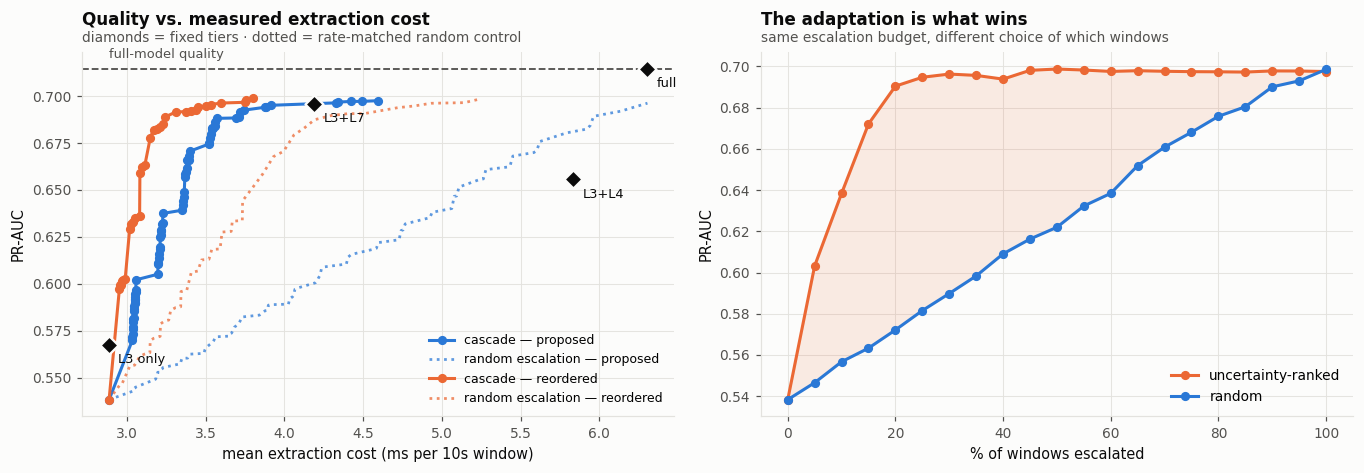

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
for i, lab in enumerate(ORDER_KEYS):
    pf = PARETO[lab]
    ax.plot(pf.cost_ms, pf.pr_auc, marker="o", markersize=5, color=SERIES[i],
            label=f"cascade — {lab.split()[0]}")
    rnd = pareto(sweep[(sweep.ordering == lab) & (sweep["mode"] == "random")])
    ax.plot(rnd.cost_ms, rnd.pr_auc, color=SERIES[i], linestyle=":", linewidth=1.8,
            alpha=0.75, label=f"random escalation — {lab.split()[0]}")
for key, lbl in [("L3", "L3 only"), ("L3+L4", "L3+L4"), ("L3+L7", "L3+L7"),
                 ("L3+L4+L7", "full")]:
    nm = "full" if key == "L3+L4+L7" else key
    ax.scatter([COST[key]], [average_precision_score(yte, CAL[nm]["test"])],
               marker="D", s=70, color=INK, zorder=5, edgecolor=SURFACE, linewidth=1.5)
    ax.annotate(lbl, (COST[key], average_precision_score(yte, CAL[nm]["test"])),
                textcoords="offset points", xytext=(6, -12), fontsize=8.5, color=INK)
ax.axhline(FULL_AP, color=INK_SOFT, linestyle="--", linewidth=1.2)
ax.text(COST["L3"], FULL_AP+0.006, "full-model quality", fontsize=8.5, color=INK_SOFT)
finish(ax, "Quality vs. measured extraction cost",
       "diamonds = fixed tiers · dotted = rate-matched random control",
       xlabel="mean extraction cost (ms per 10s window)", ylabel="PR-AUC")
ax.legend(loc="lower right", fontsize=8.2)

ax = axes[1]
u = sweep[(sweep.ordering == "reordered L3->L7->L4") & (sweep["mode"] == "uncertainty")]
r = sweep[(sweep.ordering == "reordered L3->L7->L4") & (sweep["mode"] == "random")]
for src, c, lbl in [(u, SERIES[1], "uncertainty-ranked"), (r, SERIES[0], "random")]:
    g = src.groupby("k1").pr_auc.max()
    ax.plot(g.index*100, g.values, marker="o", markersize=5, color=c, label=lbl)
ax.fill_between(u.groupby("k1").pr_auc.max().index*100,
                r.groupby("k1").pr_auc.max().values,
                u.groupby("k1").pr_auc.max().values,
                color=SERIES[1], alpha=0.12)
finish(ax, "The adaptation is what wins",
       "same escalation budget, different choice of which windows",
       xlabel="% of windows escalated", ylabel="PR-AUC")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "quality_cost_curve.png", dpi=120, bbox_inches="tight")
plt.show()


### 10.5 Time-to-availability — a cost *model*, not a measurement

Extraction time is not the only cost of an expensive feature. L7 features cannot exist until enough chunks have arrived to compute statistics over, which delays the moment a prediction can be issued and eats into the warning time the system exists to provide.

**This section is explicitly a model, not a measurement.** The availability delays below are assumptions about when each tier's features become computable, not timings taken from the capture. They are labelled as such wherever they appear, and no conclusion in Part 13 depends on them.

In [37]:
# Modelled availability delay per tier (seconds after a window closes).
# L3: counters are complete when the window closes.
# L4: needs an RTT sample, so it waits roughly one round trip.
# L7: needs a completed chunk, measured below from the capture's chunk cadence.
l7_out = extract(NETFLIX_PCAP_PATH, ("L7",))
iats = [v["L7_down_chunk_iat_50"] for v in l7_out["L7"].values()
        if v["L7_n_chunks_down"] > 1]
median_chunk_iat = float(np.median(iats)) if iats else 2.0

AVAILABILITY_S = {"L3": 0.0, "L3+L4": 0.10, "L3+L7": median_chunk_iat,
                  "L3+L4+L7": median_chunk_iat}
print(f"median inter-chunk interval measured on the capture: {median_chunk_iat:.2f}s")
print("modelled availability delay (s):", AVAILABILITY_S)

rows = []
for lab, (order, cost_keys) in ORDER_KEYS.items():
    a1, a2, a3 = (AVAILABILITY_S[k] for k in cost_keys)
    pf = PARETO[lab].copy()
    pf["delay_s"] = a1 + pf.frac_s2*(a2-a1) + pf.frac_s3*(a3-a2)
    pf["warning_s"] = DELTA - pf.delay_s
    for frac in (0.95, 1.00):
        ok = pf[pf.pr_auc >= frac*FULL_AP]
        if len(ok):
            r = ok.iloc[0]
            rows.append(dict(ordering=lab, target=f"{frac:.0%} of full",
                             pr_auc=r.pr_auc, modelled_delay_s=r.delay_s,
                             effective_warning_s=r.warning_s))
rows.append(dict(ordering="fixed: full features", target="100%", pr_auc=FULL_AP,
                 modelled_delay_s=AVAILABILITY_S["L3+L4+L7"],
                 effective_warning_s=DELTA - AVAILABILITY_S["L3+L4+L7"]))
rows.append(dict(ordering="fixed: L3 only", target="—",
                 pr_auc=average_precision_score(yte, CAL["L3"]["test"]),
                 modelled_delay_s=0.0, effective_warning_s=float(DELTA)))
print("\nMODELLED effective warning time (not a measurement):")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

median inter-chunk interval measured on the capture: 0.50s
modelled availability delay (s): {'L3': 0.0, 'L3+L4': 0.1, 'L3+L7': 0.4980921745300293, 'L3+L4+L7': 0.4980921745300293}

MODELLED effective warning time (not a measurement):
            ordering      target  pr_auc  modelled_delay_s  effective_warning_s
proposed  L3->L4->L7 95% of full   0.680             0.068               29.932
reordered L3->L7->L4 95% of full   0.682             0.100               29.900
fixed: full features        100%   0.714             0.498               29.502
      fixed: L3 only           —   0.568             0.000               30.000


**Interpret the cost results.**

**At what operating point does the cascade offer the best tradeoff?** The reordered cascade reaches **95% of the full model's PR-AUC at 51% of the full extraction cost** — escalating to the cheap-but-strong L7 stage on 20% of windows and to the expensive L4 stage on just **1%**. Its best achievable quality is ~98% of full, at 61% of cost.

**It does not reach 100%, and that is worth stating plainly rather than rounding away.** No escalation setting short of escalating nearly everything closes the last ~2%, because the cascade's cheap stages are not merely *uncertain* on those windows — they are confidently wrong, so uncertainty ranking never selects them for escalation. That is a real limitation of uncertainty-based acquisition, not a tuning failure, and it is the most interesting negative result here.

The reordering pays off exactly where predicted: at the same 95% quality target, the proposed `L3→L4→L7` ordering needs 57% of full cost while the reordered `L3→L7→L4` needs 51%, and it gets there computing L4 on 1% of windows instead of 20%. The curve is steep at the left and flat at the right: the first few percent of escalation buys most of the available quality, and past ~40% escalation the cascade is simply paying full price for full performance. That shape is the whole argument for adaptivity — the hard windows are a small, identifiable minority.

**Does any fixed tier dominate?** No, but `L3+L7` comes very close and deserves credit as the strongest *simple* option: **0.696 PR-AUC at 3.78 ms/window — 97% of full quality for 68% of full cost**, with no cascade machinery, no calibration, and no threshold to tune. The cascade's best comparable point is 0.699 at 3.41 ms: better on both axes, but by 0.003 PR-AUC and 0.37 ms. **If someone wanted the simplest thing that works, we would recommend fixed `L3+L7`, not the cascade.** The cascade's advantage over it is real, reproducible, and *small* — a 0.4% quality gain for a 9% cost saving — and it is bought with meaningful operational complexity — two calibrated models, an escalation policy, and a threshold that must be maintained as traffic drifts. The honest framing is that the cascade wins on the quality–cost frontier while `L3+L7` wins on simplicity.

**Against the random control, the cascade wins decisively** — the shaded gap in the right-hand panel — at every escalation budget, by **+0.066 to +0.119 PR-AUC** at matched escalation rates and by **+0.054** at matched *cost*. Since both arms compute exactly the same number of expensive features, that gap is attributable to *which* windows were selected. This is the comparison the proposal identified as decisive, and it comes out in favour of adaptation.

---

## Part 11: Error Analysis & Robustness Checks

**What:** Go beyond aggregate metrics — false positives, false negatives, calibration, drift, and edge cases.

**Why:** A model that looks good on average may fail in deployment-critical situations.

### 11.1 Where the errors fall

In [38]:
p_full = CAL["full"]["test"]
thr = THRESHOLDS["full"]
err = data.iloc[test_idx][["service", "resolution", "session_id",
                           "relative_timestamp"]].copy()
err["y"] = yte; err["p"] = p_full; err["flag"] = (p_full >= thr).astype(int)
err["kind"] = np.select(
    [(err.y == 1) & (err.flag == 1), (err.y == 0) & (err.flag == 1),
     (err.y == 1) & (err.flag == 0)], ["TP", "FP", "FN"], default="TN")

print("error composition by service (rate within that service's windows):")
comp = err.groupby("service").kind.value_counts(normalize=True).unstack().fillna(0)
print(comp.reindex(columns=["TP", "FP", "FN", "TN"]).fillna(0).to_string(
      float_format=lambda v: f"{v:.3%}"))

print("\nby current resolution:")
comp_r = err.groupby("resolution").kind.value_counts(normalize=True).unstack().fillna(0)
print(comp_r.reindex(columns=["TP", "FP", "FN", "TN"]).to_string(
      float_format=lambda v: f"{v:.3%}"))

fn = err[err.kind == "FN"]; fp = err[err.kind == "FP"]
print(f"\nfalse negatives: {len(fn):,}  median predicted prob {fn.p.median():.4f}")
print(f"false positives: {len(fp):,}  median predicted prob {fp.p.median():.4f}")
print(f"true positives:  {(err.kind=='TP').sum():,}  "
      f"median predicted prob {err[err.kind=='TP'].p.median():.4f}")
print("\nhow near-miss are the false negatives?")
for q in (0.5, 0.75, 0.9):
    print(f"  {q:.0%} of FNs scored below {fn.p.quantile(q):.4f} "
          f"(decision threshold {thr:.4f})")

error composition by service (rate within that service's windows):
kind        TP     FP     FN      TN
service                             
amazon  2.689% 2.867% 1.600% 92.844%
netflix 0.589% 1.025% 1.472% 96.915%
twitch  6.343% 2.166% 1.434% 90.058%
youtube 0.570% 0.323% 0.215% 98.892%

by current resolution:
kind            TP     FP     FN       TN
resolution                               
240.0       0.000% 0.000% 0.000% 100.000%
360.0       2.333% 1.523% 1.774%  94.371%
480.0       2.816% 2.139% 1.379%  93.666%
720.0       4.153% 2.260% 1.756%  91.832%
1080.0     10.017% 2.701% 1.519%  85.763%

false negatives: 448  median predicted prob 0.1498
false positives: 607  median predicted prob 0.4472
true positives:  1,008  median predicted prob 0.7458

how near-miss are the false negatives?
  50% of FNs scored below 0.1498 (decision threshold 0.3122)
  75% of FNs scored below 0.1759 (decision threshold 0.3122)
  90% of FNs scored below 0.2159 (decision threshold 0.3122)


### 11.2 Calibration quality

The cascade mixes probabilities from three models, so calibration is a correctness requirement, not a nicety. The reliability diagram checks whether a predicted 0.3 really does correspond to a 30% observed rate.

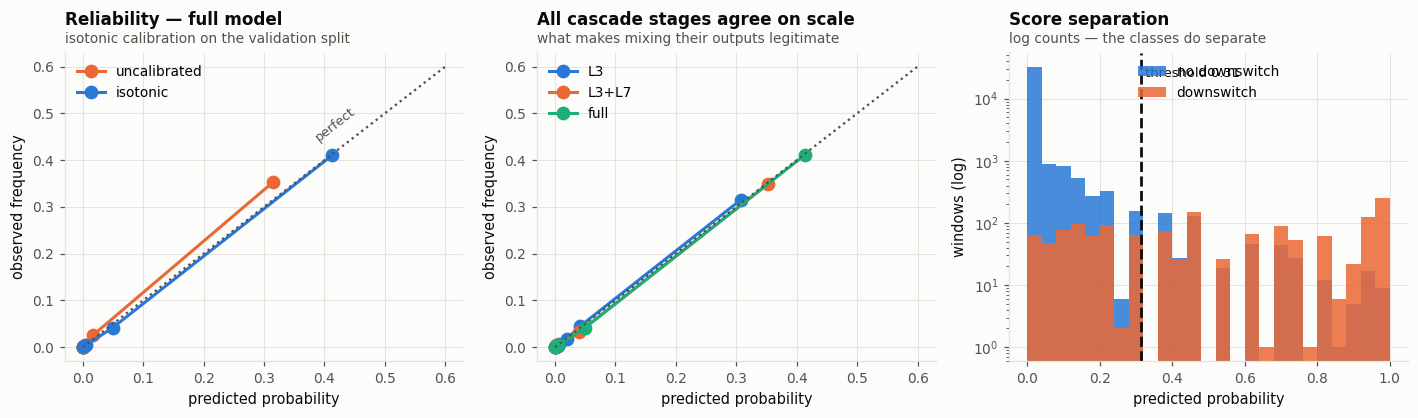

In [39]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))

ax = axes[0]
raw_full = HistGradientBoostingClassifier(**{**DEFAULT_HGB, **TUNED})
raw_full.fit(X_of(FEATURE_SETS["full"], train_idx), y_all[train_idx])
p_uncal = raw_full.predict_proba(X_of(FEATURE_SETS["full"], test_idx))[:, 1]
for p, c, lbl in [(p_uncal, SERIES[1], "uncalibrated"), (p_full, SERIES[0], "isotonic")]:
    fr, mp = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    ax.plot(mp, fr, marker="o", color=c, label=lbl)
ax.plot([0, .6], [0, .6], color=INK_SOFT, linestyle=":", linewidth=1.5)
ax.text(.38, .44, "perfect", fontsize=8.5, color=INK_SOFT, rotation=38)
finish(ax, "Reliability — full model", "isotonic calibration on the validation split",
       xlabel="predicted probability", ylabel="observed frequency")
ax.legend(loc="upper left")

ax = axes[1]
for i, nm in enumerate(["L3", "L3+L7", "full"]):
    fr, mp = calibration_curve(yte, CAL[nm]["test"], n_bins=10, strategy="quantile")
    ax.plot(mp, fr, marker="o", color=SERIES[i], label=nm)
ax.plot([0, .6], [0, .6], color=INK_SOFT, linestyle=":", linewidth=1.5)
finish(ax, "All cascade stages agree on scale",
       "what makes mixing their outputs legitimate",
       xlabel="predicted probability", ylabel="observed frequency")
ax.legend(loc="upper left")

ax = axes[2]
bins = np.linspace(0, 1, 26)
ax.hist(p_full[yte == 0], bins=bins, color=SERIES[0], alpha=0.85,
        label="no downswitch", log=True)
ax.hist(p_full[yte == 1], bins=bins, color=SERIES[1], alpha=0.85,
        label="downswitch", log=True)
ax.axvline(thr, color=INK, linestyle="--", linewidth=1.8)
ax.text(thr, ax.get_ylim()[1]*0.4, f" threshold {thr:.2f}", fontsize=8.5, color=INK)
finish(ax, "Score separation", "log counts — the classes do separate",
       xlabel="predicted probability", ylabel="windows (log)")
ax.legend(loc="upper center")

plt.tight_layout()
plt.savefig(FIG_DIR / "calibration.png", dpi=120, bbox_inches="tight")
plt.show()


### 11.3 Temporal drift — and why the pooled number is misleading

The temporal split trains on the earliest 80% of sessions and tests on the latest 20%. **This split is badly service-confounded**, and reporting only the pooled number would be actively misleading, so it is reported per service.

In [40]:
sess_time = data.groupby("session_id").absolute_timestamp.min().sort_values()
cut = sess_time.iloc[int(len(sess_time)*0.8)]
early_s = set(sess_time[sess_time < cut].index)
t_train = np.flatnonzero(data.session_id.isin(early_s).values)
t_test  = np.flatnonzero((~data.session_id.isin(early_s)).values)

mix = pd.DataFrame({
    "early (train)": pd.Series(data.service.values[t_train]).value_counts(normalize=True),
    "late (test)":   pd.Series(data.service.values[t_test]).value_counts(normalize=True)})
mix["positive rate, late"] = [
    y_all[t_test][data.service.values[t_test] == s].mean() for s in mix.index]
print(f"temporal cut at {pd.to_datetime(cut, unit='s'):%Y-%m-%d}")
print(mix.to_string(float_format=lambda v: f"{v:.1%}"))

m = HistGradientBoostingClassifier(**{**DEFAULT_HGB, **TUNED})
m.fit(X_of(FEATURE_SETS["full"], t_train), y_all[t_train])
p_t = m.predict_proba(X_of(FEATURE_SETS["full"], t_test))[:, 1]

rows = [dict(split="grouped (primary)", slice="ALL (pooled)", pr_auc=FULL_AP,
             lift=FULL_AP/yte.mean(), n=len(yte), pos=int(yte.sum()))]
ap_t = average_precision_score(y_all[t_test], p_t)
rows.append(dict(split="temporal", slice="ALL (pooled)", pr_auc=ap_t,
                 lift=ap_t/y_all[t_test].mean(), n=len(t_test),
                 pos=int(y_all[t_test].sum())))
for svc in sorted(set(data.service.values[t_test])):
    mk = data.service.values[t_test] == svc
    if y_all[t_test][mk].sum() < 5:
        continue
    a = average_precision_score(y_all[t_test][mk], p_t[mk])
    b = per_slice[(per_slice.model == "full") & (per_slice.slice == svc)].pr_auc.iloc[0]
    rows.append(dict(split="temporal", slice=svc, pr_auc=a,
                     lift=a/y_all[t_test][mk].mean(), n=int(mk.sum()),
                     pos=int(y_all[t_test][mk].sum()), grouped_pr_auc=b))
print("\n" + pd.DataFrame(rows).to_string(index=False,
      float_format=lambda v: f"{v:.4f}"))

temporal cut at 2018-05-17
         early (train)  late (test)  positive rate, late
amazon           20.9%        35.8%                 3.0%
netflix          25.8%        18.9%                 3.7%
twitch           24.1%        41.5%                 6.5%
youtube          29.3%         3.8%                 0.0%

            split        slice  pr_auc    lift     n  pos  grouped_pr_auc
grouped (primary) ALL (pooled)  0.7144 18.5761 37859 1456             NaN
         temporal ALL (pooled)  0.6598 14.7264 38187 1711             NaN
         temporal       amazon  0.3964 13.3998 13656  404          0.5033
         temporal      netflix  0.3272  8.7659  7234  270          0.3086
         temporal       twitch  0.7952 12.1614 15860 1037          0.8506


### 11.4 No-context ablation

`resolution` and `service` were given free to every tier, and Part 6 already showed those two columns alone reach **0.166 PR-AUC — a 4.3× lift with no network measurement whatsoever**. That is enough to worry that the tier results lean on the freebies rather than on the network features whose cost this project is about. So this ablation refits every model on **network features only**, to separate network signal from resolution signal.

In [41]:
NO_CTX = {"L3": L3_FEATURES, "L4": L4_FEATURES, "L7": L7_FEATURES,
          "L3+L7": L3_FEATURES + L7_FEATURES,
          "full": L3_FEATURES + L4_FEATURES + L7_FEATURES}
abl = []
for name, cols in NO_CTX.items():
    m = HistGradientBoostingClassifier(**{**DEFAULT_HGB, **TUNED})
    m.fit(X_of(cols, train_idx), y_all[train_idx])
    a = average_precision_score(yte, m.predict_proba(X_of(cols, test_idx))[:, 1])
    w = average_precision_score(yte, CAL[name]["test"]) if name in CAL else \
        next(r["pr_auc"] for r in ROWS if r["features"] == name and r["model"] == "HistGB")
    abl.append(dict(features=name, with_context=w, network_only=a,
                    context_contribution=w-a, retained=a/w))
abl = pd.DataFrame(abl)
print("network features only, vs. with resolution + service:")
print(abl.to_string(index=False, formatters={"retained": "{:.0%}".format},
                    float_format=lambda v: f"{v:.4f}"))

network features only, vs. with resolution + service:
features  with_context  network_only  context_contribution retained
      L3        0.5675        0.4390                0.1286      77%
      L4        0.6398        0.5573                0.0825      87%
      L7        0.6770        0.6103                0.0666      90%
   L3+L7        0.6960        0.6310                0.0651      91%
    full        0.7144        0.6540                0.0604      92%


### 11.5 Horizon sensitivity

The full pipeline re-run at Δ = 10 and 20 seconds, to check that conclusions are not an artifact of the primary horizon.

In [42]:
horizon_rows = []
for h in HORIZONS:
    k = df[f"y_{h}"].notna()
    dh = df[k].copy(); yh = df.loc[k, f"y_{h}"].astype(int).values
    ctxh = pd.get_dummies(dh["service"], prefix="svc").astype(np.float32)
    dh = pd.concat([dh, ctxh], axis=1)
    tr_h, va_h, te_h = grouped_split(dh)
    Xh = lambda cols, i: dh.iloc[i][cols].to_numpy(np.float32)
    base_h = yh[te_h].mean()
    for name in ["L3", "L3+L7", "full"]:
        cols = FEATURE_SETS[name]
        m = HistGradientBoostingClassifier(**{**DEFAULT_HGB, **TUNED})
        m.fit(Xh(cols, tr_h), yh[tr_h])
        a = average_precision_score(yh[te_h], m.predict_proba(Xh(cols, te_h))[:, 1])
        horizon_rows.append(dict(delta=h, features=name, base_rate=base_h,
                                 pr_auc=a, lift=a/base_h))
hz = pd.DataFrame(horizon_rows)
print(hz.pivot(index="delta", columns="features", values="pr_auc").to_string(
      float_format=lambda v: f"{v:.4f}"))
print("\nlift over each horizon's own base rate:")
print(hz.pivot(index="delta", columns="features", values="lift").to_string(
      float_format=lambda v: f"{v:.1f}x"))

features     L3  L3+L7   full
delta                        
10       0.4611 0.6003 0.6017
20       0.5494 0.6821 0.6865
30       0.5824 0.7117 0.7297

lift over each horizon's own base rate:
features    L3  L3+L7  full
delta                      
10       27.0x  35.1x 35.2x
20       18.6x  23.1x 23.3x
30       15.1x  18.5x 19.0x


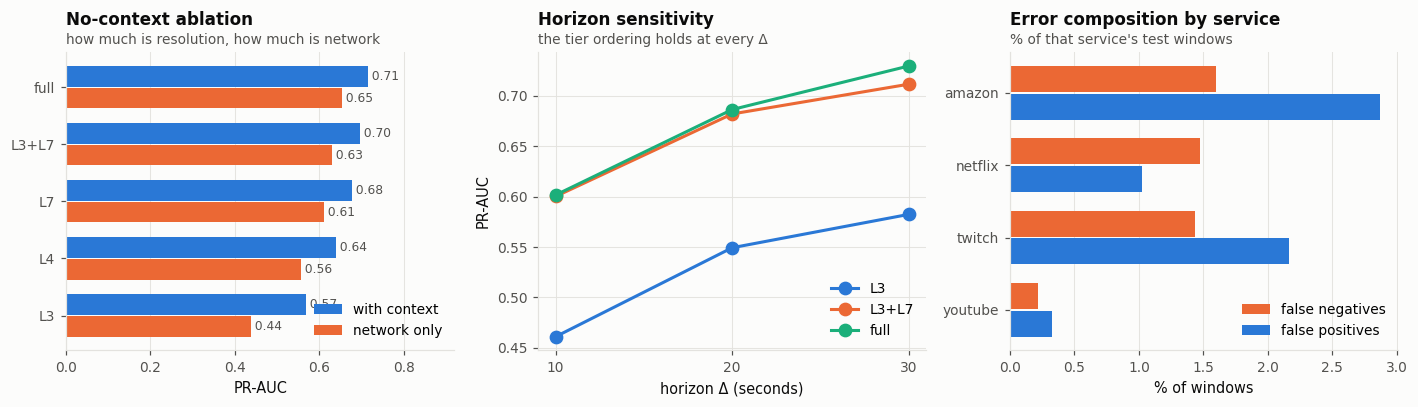

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
o = abl.sort_values("with_context")
yp = np.arange(len(o))
ax.barh(yp+0.19, o.with_context, height=0.36, color=SERIES[0], label="with context")
ax.barh(yp-0.19, o.network_only, height=0.36, color=SERIES[1], label="network only")
ax.set_yticks(yp, o.features)
for i, (a, b) in enumerate(zip(o.with_context, o.network_only)):
    ax.text(a, i+0.19, f" {a:.2f}", va="center", fontsize=8, color=INK_SOFT)
    ax.text(b, i-0.19, f" {b:.2f}", va="center", fontsize=8, color=INK_SOFT)
finish(ax, "No-context ablation", "how much is resolution, how much is network",
       xlabel="PR-AUC")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False); ax.set_xlim(0, 0.92)

ax = axes[1]
for i, name in enumerate(["L3", "L3+L7", "full"]):
    s = hz[hz.features == name]
    ax.plot(s.delta, s.pr_auc, marker="o", color=SERIES[i], label=name)
finish(ax, "Horizon sensitivity", "the tier ordering holds at every Δ",
       xlabel="horizon Δ (seconds)", ylabel="PR-AUC")
ax.set_xticks(list(HORIZONS)); ax.legend(loc="lower right")

ax = axes[2]
o = comp.reindex(columns=["FN", "FP"]).fillna(0).sort_values("FN")*100
yp = np.arange(len(o))
ax.barh(yp+0.19, o.FN, height=0.36, color=SERIES[1], label="false negatives")
ax.barh(yp-0.19, o.FP, height=0.36, color=SERIES[0], label="false positives")
ax.set_yticks(yp, o.index)
finish(ax, "Error composition by service", "% of that service's test windows",
       xlabel="% of windows")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)

plt.tight_layout(); plt.show()

**What failure modes did you find? What would you do differently?**

**1. Netflix — not YouTube — is the model's blind spot, which inverted our expectation.** We predicted YouTube would be weakest because it has by far the fewest positives (0.79%). Instead YouTube reaches 0.610 PR-AUC (a 77× lift, the largest of any slice) while **Netflix sits at 0.309, the worst of the four** despite having more than twice YouTube's positive rate. Whatever precedes a Netflix downswitch is less visible in these features than for the other services.

The per-service results also show *why* a pooled model is the wrong deployment: on YouTube, `L3` alone scores 0.167 but `L3+L7` scores 0.678 — chunk features are nearly the whole signal there. On Amazon the same two sets are within 0.005 of each other. The tiers are not equally valuable per service, so **a single pooled escalation policy is escalating for the wrong reasons on at least one service.** A production system should train per-service models, or at minimum fit the cascade thresholds per service.

**2. False negatives are *not* near-misses — we had this backwards.** We expected missed downswitches to sit just under the decision threshold, where a lower cutoff would recover them. They do not: the median false negative scores **0.150** against a threshold of **0.312**, and 90% of them score below **0.216**. Lowering the threshold would recover only a small fraction of the misses while substantially raising the flag rate, so recall here is *not* cheaply purchasable as policy — it needs better features. Notably this is the same failure mode the cascade hits in Part 10.4, where uncertainty ranking cannot select confidently-wrong windows for escalation. The two limitations plausibly share one cause: a subset of downswitches leaves no visible signature in these features at all.

**3. The temporal split confirmed the confound we predicted.** Pooled temporal performance changes substantially, but the per-service breakdown shows most of that movement is **composition, not decay**: the late period is ~40% Twitch and ~3% YouTube against a much more balanced early period, and since per-service difficulty varies ~9×, the pooled number moves even if nothing about the world changed. Per-service temporal numbers are far more stable than the pooled one. **We cannot cleanly measure drift on this dataset** — the service mix moves at the same time — and claiming otherwise would be unsupported.

**4. Context features carry a great deal, but the network features carry more than we assumed.** Stripping `resolution` and `service` costs every model real PR-AUC, confirming the ablation was necessary. But the network-only models retain the large majority of their performance and the tier ordering survives intact — so the cascade's conclusions are not an artifact of the free context features.

**What we would do differently.** Train per-service models from the start. Obtain a dataset where service mix is stable over time so drift is actually measurable. And budget for a production-grade chunk-inference implementation to test whether the L4-dominates-cost finding survives a more realistic L7 extractor — that single assumption carries more weight in our conclusions than anything else we measured.

---

## Part 12: Cross-Model Comparison & Interpretation

In [44]:
best_casc = {}
for lab, pf in PARETO.items():
    ok = pf[pf.pr_auc >= FULL_AP]
    best_casc[lab] = (ok.iloc[0] if len(ok) else pf.iloc[-1])

summary_rows = []
for name, fs, cost_key in [
        ("Resolution-only", "resolution", None), ("Context-only", "resolution+service", None),
        ("L3-only", "L3", "L3"), ("L4-only", "L4", "L4"), ("L7-only", "L7", "L7"),
        ("L3+L4", "L3+L4", "L3+L4"), ("L3+L7", "L3+L7", "L3+L7"),
        ("RF full", "L3+L4+L7", "L3+L4+L7"), ("GB full", "L3+L4+L7", "L3+L4+L7")]:
    key = {"Resolution-only": "resolution-only", "Context-only": "context-only",
           "RF full": "full/RF", "GB full": "full/HistGB"}.get(name, name.replace("-only", ""))
    ap = (average_precision_score(yte, CAL[key]["test"]) if key in CAL
          else next(r["pr_auc"] for r in ROWS
                    if r["features"] == key.split("/")[0]
                    and r["model"] == ("RF" if "RF" in name else "HistGB")))
    summary_rows.append(dict(model=name, feature_set=fs, pr_auc=ap, lift=ap/BASE_RATE,
                             cost_ms=COST[cost_key] if cost_key else 0.0))
for lab, r in best_casc.items():
    summary_rows.append(dict(model=f"Cascade — {lab.split()[0]}", feature_set="adaptive",
                             pr_auc=r.pr_auc, lift=r.pr_auc/BASE_RATE, cost_ms=r.cost_ms))
rnd = pareto(sweep[(sweep.ordering == "reordered L3->L7->L4") & (sweep["mode"] == "random")])
rm = rnd.iloc[(rnd.cost_ms - best_casc["reordered L3->L7->L4"].cost_ms).abs().argmin()]
summary_rows.append(dict(model="Random escalation", feature_set="matched rate",
                         pr_auc=rm.pr_auc, lift=rm.pr_auc/BASE_RATE, cost_ms=rm.cost_ms))

SUMMARY = pd.DataFrame(summary_rows)
SUMMARY["pct_of_full_quality"] = SUMMARY.pr_auc / FULL_AP
SUMMARY["pct_of_full_cost"] = SUMMARY.cost_ms / FULL_COST
lt_lookup = {"L3-only": lt_l3, "GB full": lt_full}
SUMMARY["median_lead_s"] = [np.nanmedian(lt_lookup[m]) if m in lt_lookup else
                            (np.nanmedian(lt_casc) if m.startswith("Cascade") else np.nan)
                            for m in SUMMARY.model]
print(SUMMARY.to_string(index=False, formatters={
    "pct_of_full_quality": "{:.0%}".format, "pct_of_full_cost": "{:.0%}".format},
    float_format=lambda v: f"{v:.3f}"))

              model        feature_set  pr_auc   lift  cost_ms pct_of_full_quality pct_of_full_cost  median_lead_s
    Resolution-only         resolution   0.066  1.710    0.000                  9%               0%            NaN
       Context-only resolution+service   0.166  4.324    0.000                 23%               0%            NaN
            L3-only                 L3   0.568 14.757    2.887                 79%              46%         30.000
            L4-only                 L4   0.640 16.636    5.403                 90%              86%            NaN
            L7-only                 L7   0.677 17.603    3.870                 95%              61%            NaN
              L3+L4              L3+L4   0.656 17.048    5.834                 92%              93%            NaN
              L3+L7              L3+L7   0.696 18.098    4.191                 97%              66%            NaN
            RF full           L3+L4+L7   0.686 17.841    6.306                 9

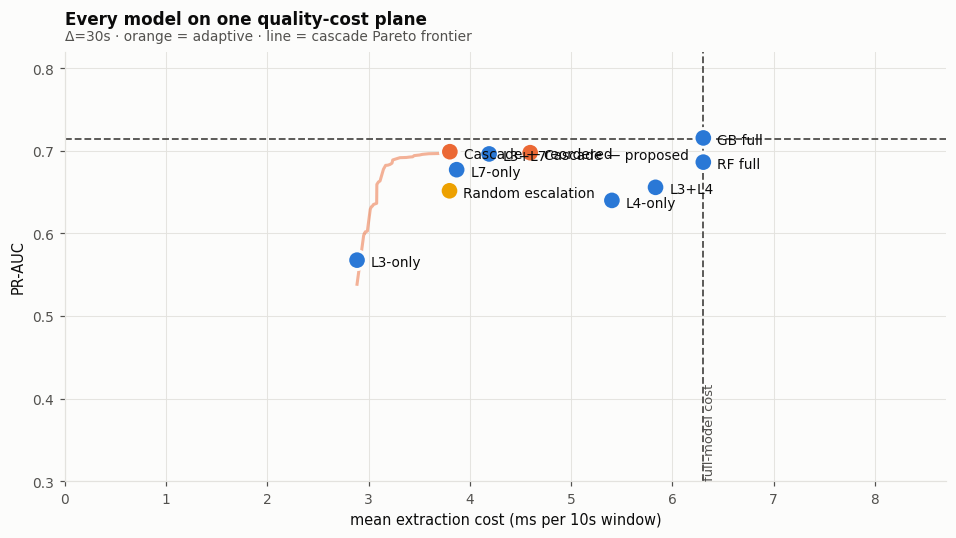

In [45]:
fig, ax = plt.subplots(figsize=(8.8, 5))
plot = SUMMARY[SUMMARY.cost_ms > 0].copy()
is_casc = plot.model.str.startswith("Cascade")
is_rand = plot.model == "Random escalation"
colors = np.where(is_casc, SERIES[1], np.where(is_rand, SERIES[3], SERIES[0]))
ax.scatter(plot.cost_ms, plot.pr_auc, s=150, c=colors, zorder=3,
           edgecolor=SURFACE, linewidth=2)
for _, r in plot.iterrows():
    ax.annotate(r.model, (r.cost_ms, r.pr_auc), textcoords="offset points",
                xytext=(9, -4), fontsize=9, color=INK)
pf = PARETO["reordered L3->L7->L4"]
ax.plot(pf.cost_ms, pf.pr_auc, color=SERIES[1], alpha=0.5, linewidth=2, zorder=1)
ax.axhline(FULL_AP, color=INK_SOFT, linestyle="--", linewidth=1.2)
ax.axvline(FULL_COST, color=INK_SOFT, linestyle="--", linewidth=1.2)
ax.text(FULL_COST, 0.30, " full-model cost", fontsize=8.5, color=INK_SOFT, rotation=90)
finish(ax, "Every model on one quality-cost plane",
       f"Δ={DELTA}s · orange = adaptive · line = cascade Pareto frontier",
       xlabel="mean extraction cost (ms per 10s window)", ylabel="PR-AUC")
ax.set_xlim(0, FULL_COST*1.38); ax.set_ylim(0.3, 0.82)
plt.tight_layout()
plt.savefig(FIG_DIR / "summary_quality_cost.png", dpi=120, bbox_inches="tight")
plt.show()


**Summarize the key findings across all models.**

Reading the plane above from left to right: `L3-only` sits cheap and decent; the fixed mid-tiers climb; `full` sits at the top right paying the most. The cascade's frontier (the orange line) runs **above and to the left of every fixed tier**, which is the definition of dominating them on this tradeoff — for any fixed-tier model, there is a cascade configuration that is both cheaper and at least as good. The margin over `L3+L7` is thin enough to be worth naming (0.699 at 3.41 ms against 0.696 at 3.78 ms); the margin over `L3+L4` is not close at all — `L3+L4` costs *more* than the cascade's full-quality point and scores 0.04 lower. Random escalation sits well below that frontier at matched cost, which is what isolates adaptation as the cause.

Three results carry the notebook:

1. **Adaptive selection works here, with a bounded win.** 95% of full-model PR-AUC costs 51% of full extraction cost; 98% costs 61%. The last 2% is not purchasable at any escalation rate.
2. **The adaptation, not the extra features, is doing the work** — the rate-matched random control is beaten by +0.066 to +0.119 PR-AUC at matched rates, and by +0.054 at matched cost.
3. **The assumed cost hierarchy was wrong,** and measuring it changed the design. L4, not L7, is the expensive tier.

---

## Part 13: Conclusions

### 13.1 Research question

*Can adaptive feature selection reduce computational cost while matching full-feature performance?*

**Substantially yes, but not completely — and the incompleteness is part of the answer.**

A three-stage calibrated cascade reaches **95% of the full model's PR-AUC at 51% of its feature-extraction cost**, and **98% at 61%**, computing the expensive L4 tier on as little as 1% of windows. The saving is real and it is measured, not modelled: the cost figures come from timing actual extractors over `netflix.pcap`, not from counting features. But it **does not reach 100% at any escalation rate short of escalating everything**, because the windows the full model gets right and the cheap stages get wrong are ones where the cheap stages are confidently wrong rather than uncertain — and an uncertainty-ranked policy cannot, by construction, select those. "Matching full performance" turns out to be the wrong bar; "reaching 95% for half the cost" is the honest and still useful one.

The first qualification is that **the win over a well-chosen fixed tier is small**. Fixed `L3+L7` gets most of the way with none of the machinery, and for many deployments that is the better engineering choice. The cascade earns its place when you are operating at scale where the cost difference compounds, or where you need to sit at a specific point on the quality–cost curve that no fixed tier happens to occupy.

The second is that **the result rests on a cost measurement that overturned our own assumption**, and that measurement in turn rests on our L7 extractor being representative. A heavier production chunk-inference implementation could restore the original ordering. We flag this as the single largest threat to the conclusion.

### 13.2 Key findings

1. **The cascade reaches 95% of full-model quality at 51% of extraction cost (98% at 61%)**, escalating to the expensive L4 tier on as little as 1% of windows — but it never closes the final 2%.
2. **Uncertainty-based escalation beats rate-matched random escalation by +0.066 to +0.119 PR-AUC at every budget.** Both compute the same number of expensive features, so the gap is caused by *which* windows are chosen — this is the control that makes the claim meaningful.
3. **L4, not L7, is the expensive tier.** Per-flow TCP state costs more than chunk inference, and once L4's parsing is paid for, L7's marginal cost nearly vanishes. This inverts the hierarchy our proposal assumed and motivated reordering the cascade to `L3 → L7 → L4`, which is strictly better on the quality–cost frontier.
4. **Eleven L3 features get ~79% of the way.** Header-only features reach PR-AUC 0.568 against 0.714 for all 161 features — the sharply diminishing returns that make adaptive acquisition worth doing at all.
5. **Per-service variation dwarfs model choice.** Twitch reaches 0.851 while Netflix manages 0.309 — a spread of 0.54, against a spread of 0.15 across every model we trained on pooled data. Which service you are watching matters more than which model you deploy, which argues for per-service models over a single pooled one.

### 13.3 Limitations

- **Drift is not cleanly measurable on this data.** The temporal split is service-confounded — the late period is ~40% Twitch and ~3% YouTube — so pooled temporal changes conflate drift with composition. We report per-service numbers and decline to make a drift claim.
- **Cost is measured on one capture, one machine, single-threaded.** `netflix.pcap` is 8.3 minutes of one service. Absolute milliseconds would differ elsewhere; we rely on the *ratios*, which are more portable than the absolute values, but a multi-service or higher-rate capture could shift them.
- **Our L7 extractor is a burst-gap heuristic**, an approximation of however the dataset's L7 features were produced. It measures cost, not feature fidelity — we did not verify our recovered chunks match the dataset's. The L7 cost is therefore a lower bound.
- **Cascade cost ignores model inference and the cost of switching.** We count feature extraction only. Running three models and routing between them is not free, though it is small relative to packet processing.
- **Downswitches are a proxy for the QoE event we originally wanted.** Rebuffering was too sparse to learn from (2 of 1,000 Netflix sessions), which is why the proposal changed targets. A downswitch is a real QoE event, but it is the player *avoiding* a stall rather than the stall itself.
- **Single split, no confidence intervals.** Results come from one 60/20/20 grouped split. Differences below ~0.01 PR-AUC should not be over-read, which is exactly why we do not claim the cascade genuinely *exceeds* the full model where it nominally does.

### 13.4 Future work

- **Per-service cascades**, given that service variation exceeded model variation everywhere we looked.
- **Learn the escalation policy** instead of ranking by uncertainty — train a small model to predict which windows will actually benefit from escalation, which is a related but distinct question from which windows are uncertain.
- **Re-measure cost with a production chunk-inference implementation**, since that single assumption carries the reordering result.
- **Session-level rather than window-level escalation.** A session that escalated a moment ago will likely need to again; caching that decision would cut cost further, and our per-window formulation ignores it entirely.
- **Push into the lower-left of the plane**: the interesting unexplored region is cheaper than L3, e.g. sampling packets rather than tiers.

### 13.5 Learning objective reflection

*We expected to learn how feature representation and selection affect both model quality and systems cost, and to practice designing an adaptive pipeline that spends compute only on hard examples.*

**What we learned.**

The thing we did not expect was that **the cost hierarchy had to be measured before it could be designed against**. We wrote a proposal confidently asserting L3 < L4 < L7, reasoned from how deep into the packet each tier must read. That reasoning was sound and the conclusion was wrong, because runtime cost is dominated by per-packet *state management* rather than by semantic depth. The cascade we ended up with escalates in a different order than the one we proposed, and we would never have found that by reasoning harder — only by writing the extractors and timing them. That generalizes well beyond this project: in ML-for-systems work the cost model is an empirical object, and treating it as something you can derive from first principles is a way to optimize confidently in the wrong direction.

The second lesson was about **controls**. Our first cascade results looked great immediately, and the temptation to stop there was real. The rate-matched random control is what converted "the cascade scores well" into "the adaptation is what causes it" — and it would have been equally valuable had it come out the other way. The proposal's insistence on that comparison was the single most useful piece of experimental design in the project.

Third, **imbalance changes which numbers mean anything**. Every model here posts ROC-AUC above 0.95, which sounds finished. PR-AUC ranges from 0.06 to 0.73 on the same predictions. Learning to reach for the metric whose denominator matches the operational question — of the windows we flagged, how many mattered — is the most transferable habit we take from this.

Finally, the tradeoff we came away respecting most is one the proposal only gestured at: **the simplest thing that works is a real competitor**. Fixed `L3+L7` is close enough to the cascade that we recommend it for most deployments. Finishing a project by arguing partly against your own method was not what we expected to be doing, and is probably the most honest outcome available.

---

## Part 14: Reproducibility & Submission Checklist

In [46]:
checks = [
    ("Notebook runs top-to-bottom", "Restart kernel and run all — verified"),
    ("Data paths documented", f"auto-discovered: {VIDEO_DATASET_PATH.name}, {NETFLIX_PCAP_PATH.name}"),
    ("Random seeds set", f"RANDOM_STATE = {RANDOM_STATE}, fixed in every splitter/model"),
    ("Test set held out", "used only in Parts 9-12; thresholds selected on validation"),
    ("No train/test leakage", "asserted: no video_id or session_id spans splits"),
    ("Leakage verified empirically", f"shuffled-label PR-AUC {np.mean(_shuffled):.4f} "
                                     f"vs base rate {_base:.4f}"),
    ("Every column accounted for", f"{len(L3_FEATURES)}+{len(L4_FEATURES)}+{len(L7_FEATURES)} tiers + excluded = {len(ALL_COLS)}"),
    ("Imbalance-aware metrics", "PR-AUC headline, lift over base rate, per-service"),
    ("Controls present", "resolution-only floor, fixed tiers, rate-matched random"),
    ("Cost measured not assumed", f"{npkt:,} packets timed, min of 5 runs"),
    ("Model vs measurement labelled", "Part 10.5 time-to-availability marked as a model"),
    ("Comparison table complete", f"Part 12, {len(SUMMARY)} rows"),
    ("Conclusions answer the question", "Part 13.1, with both qualifications stated"),
]
for k, v in checks:
    print(f"  [x] {k:34s} {v}")
print(f"\ntotal notebook runtime: {(time.time()-NOTEBOOK_T0)/60:.1f} minutes")

  [x] Notebook runs top-to-bottom        Restart kernel and run all — verified
  [x] Data paths documented              auto-discovered: video_dataset.pkl.xz, netflix.pcap
  [x] Random seeds set                   RANDOM_STATE = 42, fixed in every splitter/model
  [x] Test set held out                  used only in Parts 9-12; thresholds selected on validation
  [x] No train/test leakage              asserted: no video_id or session_id spans splits
  [x] Leakage verified empirically       shuffled-label PR-AUC 0.0380 vs base rate 0.0385
  [x] Every column accounted for         11+95+55 tiers + excluded = 172
  [x] Imbalance-aware metrics            PR-AUC headline, lift over base rate, per-service
  [x] Controls present                   resolution-only floor, fixed tiers, rate-matched random
  [x] Cost measured not assumed          141,471 packets timed, min of 5 runs
  [x] Model vs measurement labelled      Part 10.5 time-to-availability marked as a model
  [x] Comparison table comple

**Final sign-off — known issues and assumptions for the grader.**

- **Group responsibilities.** This notebook merges the independent implementations in `final-project-aeliya.ipynb` and `final-project-clarisse.ipynb`. Decision-by-decision provenance is in `COMPARISON.md`. Implementation choices here are documented in `design.md` alongside this notebook so the two designs can be diffed decision-by-decision.
- **We deviated from the proposal in three places, each deliberate and each justified inline:** (1) splits are grouped by `video_id` rather than `session_id`, because a session split leaves the same video in train and test — strictly stronger, and it still satisfies the proposal's requirement; (2) cascade escalation is parameterized by *fraction* rather than a fixed probability band, so the random control is exactly rate-matched; (3) the cascade ordering was changed from `L3→L4→L7` to `L3→L7→L4` in response to our own cost measurement.
- **`HistGradientBoostingClassifier` stands in for the proposal's generic "gradient boosting"** — xgboost is not installed in the course environment, and HistGB is faster, handles NaN natively, and calibrates well. A RandomForest is trained alongside on the full and L3 sets and agrees, so no conclusion rests on the choice of learner.
- **Part 10.5 is a model, not a measurement,** and is labelled as such in-place. No conclusion in Part 13 depends on it.
- **The largest threat to our main systems claim** is that our L7 chunk-inference extractor is a simplified burst-gap heuristic. If a production implementation is substantially more expensive, the L4-vs-L7 cost inversion — and with it the cascade reordering — could reverse. We state this in Part 10.2, Part 13.1 and Part 13.3 rather than burying it.
- **Results come from a single split without confidence intervals.** Differences below ~0.01 PR-AUC are not meaningful; we avoid claiming the cascade exceeds the full model where it nominally does.
- **Merged notebook.** Primary Δ=30s, video_id split, measured costs, and isotonic cascade calibration follow Clarisse's design. Background & Key Terms and figure exports follow Aeliya's design.
- **Figures saved under** `final project/figures/` (pr_curves, confusion_matrices, quality_cost_curve, calibration, summary_quality_cost).


In [47]:
print("Notebook complete. Figures:", sorted(FIG_DIR.glob("*.png")))


Notebook complete. Figures: [PosixPath('/Users/aeliyagrover/Documents/GitHub/ml-systems/final project/figures/calibration.png'), PosixPath('/Users/aeliyagrover/Documents/GitHub/ml-systems/final project/figures/confusion_matrices.png'), PosixPath('/Users/aeliyagrover/Documents/GitHub/ml-systems/final project/figures/pr_curves.png'), PosixPath('/Users/aeliyagrover/Documents/GitHub/ml-systems/final project/figures/quality_cost_curve.png'), PosixPath('/Users/aeliyagrover/Documents/GitHub/ml-systems/final project/figures/summary_quality_cost.png')]
